# 14 — Final Poster Analysis & Results Integration
## CHRD-Bench: Kapadokya Dil Değiştirince Değişiyor mu?
### SDXL vs FLUX.1-schnell — CCGI / CCS / TSR / Motif Analizi

Bu notebook, mevcut 01-13 notebook çıktılarını (görüntüler, metadata, benzerlik CSV'leri) okuyup:
1. Motif tabanlı **CCGI, CCS, TSR** metriklerini hesaplar (CLIP zero-shot motif tespiti ile, annotasyon dosyaların dolu değilse)
2. **Mitigation Gain** (nötr→grounded iyileşmesi) hesaplar
3. İstatistiksel testler (TR vs EN farkı, %95 CI, FDR düzeltmesi) yapar
4. Referans postere benzer **7+ panel** görsel üretir (300 DPI, PNG+PDF)
5. Bol miktarda ara çıktı/tablo basar ki poster için seçimi sen yapasın

> ⚠️ **CONFIG bölümündeki `GENERATION_FOLDERS` sözlüğünü mutlaka gözden geçir** — `v1` / `v3_768` klasörlerinin nötr mü grounded mı olduğundan emin değilim, varsayımla dolduruyorum, aşağıda uyarı olarak da basıyorum.

In [2]:
%pip install -q statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import re, json, warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["axes.titleweight"] = "bold"

PURPLE = "#7B2D8E"; GOLD = "#C9A24B"; TEAL = "#2D8E82"; RED = "#C0392B"
MODEL_PALETTE = {"SDXL": PURPLE, "FLUX": GOLD}
COND_PALETTE = {"TR-Nötr": "#8ABEDD", "EN-Nötr": "#E6A6A0", "TR-Grounded": "#7FBF7F", "EN-Grounded": "#C9A2D6"}

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)
print("Kütüphaneler yüklendi.")

Kütüphaneler yüklendi.


## 1. CONFIG — gerçek proje yapına göre dolduruldu

Attığın ekran görüntülerindeki klasör adlarını birebir kullandım. **Tek belirsizlik:** `v1` vs `v3_768` klasörlerinin nötr/grounded karşılığı — varsayımı aşağıda net yazdım, yanlışsa tek satır değiştir yeter.

In [4]:
PROJECT_ROOT = Path(".").resolve().parent
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path(".").resolve()

DATA_DIR   = PROJECT_ROOT / "data"
GEN_DIR    = DATA_DIR / "CHRD_Generated"
REAL_DIR   = DATA_DIR / "CHRD_Real"
REAL_META  = REAL_DIR / "metadata"
ANNOT_DIR  = DATA_DIR / "annotations"
RESULTS08  = PROJECT_ROOT / "results" / "poster_final"
OUT_DIR    = PROJECT_ROOT / "notebooks" / "poster_outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(exist_ok=True)
(OUT_DIR / "tables").mkdir(exist_ok=True)

# ⚠️ AYARLA: hangi klasör nötr, hangisi grounded? Şu an v1 = nötr, v3_768 = grounded varsayıyorum.
GENERATION_FOLDERS = {
    ("SDXL", "TR", "neutral"):  "SDXL_TR_v1",
    ("SDXL", "TR", "grounded"): "SDXL_TR_v3_768",
    ("SDXL", "EN", "neutral"):  "SDXL_EN_v1",
    ("SDXL", "EN", "grounded"): "SDXL_EN_v3_768",
    ("FLUX", "TR", "neutral"):  "FLUX_TR_768",
    ("FLUX", "EN", "neutral"):  "FLUX_EN_768",
    # FLUX icin grounded klasoru ayri ise buraya ekle, orn:
    # ("FLUX", "TR", "grounded"): "FLUX_TR_grounded_768",
    # ("FLUX", "EN", "grounded"): "FLUX_EN_grounded_768",
}

FILENAME_PATTERN = re.compile(r"(\d+)_CHRD_REAL_(\d+)_(TR|EN)\.png$", re.IGNORECASE)

THEMES = ["Daily Life", "Fairy Chimney", "Local Architecture",
          "Natural Landscape", "Rock-cut Heritage", "Village Square"]

TOURISTIC_MOTIFS = ["hot_air_balloon", "cave_hotel", "camel", "horse_tour",
                     "luxury_tourism", "staged_sunrise"]

# Fallback kulturel motif sozlugu — data/CHRD_Real/metadata/motifs.csv varsa ONUN icerigi
# otomatik oncelik alacak (asagidaki load_motif_vocab bakar). Yoksa bu varsayilan kullanilir.
DEFAULT_CULTURAL_MOTIFS = {
    "Daily Life": ["woman_weaving", "bread_making", "tea_drinking", "market_stall", "traditional_clothing"],
    "Fairy Chimney": ["fairy_chimney", "cave_dwelling", "volcanic_rock_cone"],
    "Local Architecture": ["stone_house", "wooden_door", "courtyard", "dovecote", "flat_roof"],
    "Natural Landscape": ["valley_view", "vineyard", "rock_formation", "canyon"],
    "Rock-cut Heritage": ["rock_cut_church", "underground_city", "cave_carving", "fresco"],
    "Village Square": ["mosque", "fountain", "village_square", "elderly_gathering"],
}

print("PROJECT_ROOT:", PROJECT_ROOT)
print("\nGENERATION_FOLDERS (kontrol et):")
for k, v in GENERATION_FOLDERS.items():
    exists = (GEN_DIR / v).exists()
    print(f"  {k} -> {v}  {'OK' if exists else '!! KLASOR YOK'}")

PROJECT_ROOT: C:\CHRD_Project

GENERATION_FOLDERS (kontrol et):
  ('SDXL', 'TR', 'neutral') -> SDXL_TR_v1  OK
  ('SDXL', 'TR', 'grounded') -> SDXL_TR_v3_768  OK
  ('SDXL', 'EN', 'neutral') -> SDXL_EN_v1  OK
  ('SDXL', 'EN', 'grounded') -> SDXL_EN_v3_768  OK
  ('FLUX', 'TR', 'neutral') -> FLUX_TR_768  OK
  ('FLUX', 'EN', 'neutral') -> FLUX_EN_768  OK


## 2. Envanter — her klasörde kaç görüntü var, isim örnekleri

In [5]:
def scan_folder(folder: Path):
    if not folder.exists():
        return pd.DataFrame(columns=["path","filename","real_id","lang_from_name"])
    rows = []
    for f in sorted(folder.glob("*.png")):
        m = FILENAME_PATTERN.search(f.name)
        real_id = m.group(2) if m else None
        lang    = m.group(3).upper() if m else None
        rows.append({"path": f, "filename": f.name, "real_id": real_id, "lang_from_name": lang})
    return pd.DataFrame(rows)

inventory_rows = []
for (model, lang, ptype), folder_name in GENERATION_FOLDERS.items():
    df_f = scan_folder(GEN_DIR / folder_name)
    df_f["model"] = model; df_f["language"] = lang; df_f["prompt_type"] = ptype
    df_f["folder"] = folder_name
    inventory_rows.append(df_f)

gen_inventory = pd.concat(inventory_rows, ignore_index=True) if inventory_rows else pd.DataFrame()
print(f"Toplam bulunan uretilmis gorsel: {len(gen_inventory)}")
display(gen_inventory.groupby(["model","language","prompt_type"]).size().rename("adet").reset_index())
gen_inventory.head(8)

Toplam bulunan uretilmis gorsel: 849


,model,language,prompt_type,adet
0,FLUX,EN,neutral,164
1,FLUX,TR,neutral,164
2,SDXL,EN,grounded,165
3,SDXL,EN,neutral,96
4,SDXL,TR,grounded,164
5,SDXL,TR,neutral,96


,path,filename,real_id,lang_from_name,model,language,prompt_type,folder
0,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
1,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0002.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
2,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0003.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
3,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0004.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
4,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0005.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
5,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0006.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
6,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0007.png,None,None,SDXL,TR,neutral,SDXL_TR_v1
7,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0008.png,None,None,SDXL,TR,neutral,SDXL_TR_v1


## 3. CHRD-Real metadata — real_id -> tema eşlemesi

`metadata_filtered.csv` / `metadata_selected.csv` / `metadata_prompts.csv` içinden ilk uygun olanı otomatik dener. Kolon adların farklıysa `REAL_META_COLMAP`'i güncelle.

In [6]:
REAL_META_COLMAP = {
    # gercek_kolon_adin : beklenen_ad
    # orn. "id": "real_id", "kategori": "theme"
}

def load_real_metadata():
    candidates = ["metadata_filtered.csv", "metadata_selected.csv", "metadata_prompts.csv", "metadata.csv"]
    for name in candidates:
        p = REAL_DIR / name
        if p.exists():
            df = pd.read_csv(p).rename(columns=REAL_META_COLMAP)
            print(f"Yuklendi: {p.name}  ({len(df)} satir)  kolonlar: {list(df.columns)}")
            return df, name
    print("!! Hicbir real-metadata dosyasi bulunamadi, tema eslemesi bos kalacak.")
    return pd.DataFrame(), None

real_meta, real_meta_src = load_real_metadata()
if not real_meta.empty:
    display(real_meta.head())

Yuklendi: metadata_filtered.csv  (164 satir)  kolonlar: ['image_id', 'file_name', 'theme', 'location', 'motif_1', 'motif_2', 'season', 'contains_people', 'quality_score', 'cultural_value', 'notes']


,image_id,file_name,theme,location,motif_1,motif_2,season,contains_people,quality_score,cultural_value,notes
0,CHRD_REAL_0001,CHRD_REAL_0001.jpeg,Rock-cut Heritage,Ürgüp,Cave House,Stone House,Summer,No,NaN,High,NaN
1,CHRD_REAL_0004,CHRD_REAL_0004.jpeg,Village Square,Ürgüp,Street,Local People,Summer,No,NaN,Medium,NaN
2,CHRD_REAL_0005,CHRD_REAL_0005.jpeg,Fairy Chimney,NaN,Rock Formation,Balloon,Summer,No,NaN,High,NaN
3,CHRD_REAL_0006,CHRD_REAL_0006.jpeg,Local Architecture,NaN,Church,Monastery,Summer,No,NaN,Low,NaN
4,CHRD_REAL_0007,CHRD_REAL_0007.jpeg,Daily Life,NaN,Stone House,Street,Summer,No,NaN,Medium,NaN


In [7]:
# real_id -> theme sozlugu olustur (kolon adi tahmini, TODO: gerekirse duzelt)
REAL_ID_COL_CANDIDATES = ["real_id", "id", "image_id", "file_id"]
THEME_COL_CANDIDATES   = ["theme", "category", "tema"]

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

real_id_col = pick_col(real_meta, REAL_ID_COL_CANDIDATES)
theme_col   = pick_col(real_meta, THEME_COL_CANDIDATES)
print("real_id kolonu:", real_id_col, "| theme kolonu:", theme_col)

if real_id_col and theme_col:
    real_meta["_real_id_str"] = real_meta[real_id_col].astype(str).str.extract(r"(\d+)")[0].str.zfill(4)
    id_to_theme = dict(zip(real_meta["_real_id_str"], real_meta[theme_col]))
    gen_inventory["real_id"] = gen_inventory["real_id"].astype(str).str.zfill(4)
    gen_inventory["theme"] = gen_inventory["real_id"].map(id_to_theme)
    print("Eslenen tema sayisi:", gen_inventory["theme"].notna().sum(), "/", len(gen_inventory))
else:
    print("!! real_id / theme kolonlari otomatik bulunamadi -> REAL_META_COLMAP'i doldur ve bu hucreyi tekrar calistir.")
    gen_inventory["theme"] = np.nan

display(gen_inventory["theme"].value_counts(dropna=False))

real_id kolonu: image_id | theme kolonu: theme
Eslenen tema sayisi: 328 / 849


theme
NaN                   521
Local Architecture    102
Daily Life             76
Rock-cut Heritage      54
Natural Landscape      40
Village Square         34
Fairy Chimney          22
Name: count, dtype: int64

## 4. Motif tespiti (CLIP zero-shot) — annotasyon dosyaları boşsa otomatik doldurur

`data/annotations/consensus.csv` doluysa onu kullanır (elle etiketlenmiş, en güvenilir). Boşsa/yoksa **CLIP zero-shot** ile her görüntü için motif olasılıklarını hesaplayıp `consensus_auto.csv` olarak kaydeder — bu senin orijinal `consensus.csv`'ni ezmez, ayrı dosya.

In [9]:
import pandas as pd
from pathlib import Path
from pandas.errors import EmptyDataError

# ============ KONFİGÜRASYON ============
# Bu değerleri kendi projenize göre ayarlayın
REAL_META = Path("./data")  # motifs.csv'nin bulunduğu klasör

DEFAULT_CULTURAL_MOTIFS = {
    "mitoloji": ["tanrı", "efsane", "kahraman", "destan"],
    "gelenek": ["düğün", "bayram", "tören", "festival"],
    "sanat": ["heykel", "resim", "müzik", "dans"],
    "mutfak": ["yemek", "tatlı", "çorba", "kebap"],
    "el sanatları": ["halı", "kilim", "seramik", "bakır"]
}

TOURISTIC_MOTIFS = ["tarihi", "doğal", "kültürel", "deniz", "dağ"]
THEMES = ["gezi", "tatil", "keşif", "macera"]

# ============ FONKSİYONLAR ============
def create_default_motif_df():
    """Varsayılan motif verileriyle DataFrame oluşturur."""
    rows = []
    
    # Kültürel motifler
    for theme, motifs in DEFAULT_CULTURAL_MOTIFS.items():
        for motif in motifs:
            rows.append({
                "theme": theme,
                "motif": motif,
                "category": "cultural"
            })
    
    # Turistik motifler
    for motif in TOURISTIC_MOTIFS:
        for theme in THEMES:
            rows.append({
                "theme": theme,
                "motif": motif,
                "category": "touristic"
            })
    
    return pd.DataFrame(rows)

def load_motif_vocab():
    """
    motifs.csv dosyasını yükler.
    Dosya yoksa, boşsa veya geçersiz formattaysa varsayılan motifleri kullanır.
    """
    p = REAL_META / "motifs.csv"
    
    if p.exists():
        try:
            df = pd.read_csv(p)
            
            # DataFrame'in boş olmadığını ve kolonların beklenen formatta olduğunu kontrol et
            if not df.empty and len(df.columns) > 0:
                required_columns = {"theme", "motif"}
                
                if required_columns.issubset(df.columns):
                    print(
                        f" motifs.csv bulundu ({len(df)} satır), "
                        f"kolonlar: {list(df.columns)} -> kullanılacak."
                    )
                    return df
                else:
                    print(
                        "  motifs.csv bulundu ancak beklenen kolonlar ('theme', 'motif') yok. "
                        "Varsayılan motif sözlüğü kullanılacak."
                    )
            else:
                print(
                    "  motifs.csv mevcut ancak boş. "
                    "Varsayılan motif sözlüğü kullanılacak."
                )
                
        except EmptyDataError:
            print(
                "  motifs.csv mevcut ancak boş dosya. "
                "Varsayılan motif sözlüğü kullanılacak."
            )
        except Exception as e:
            print(
                f"  motifs.csv okunurken hata oluştu: {e}. "
                "Varsayılan motif sözlüğü kullanılacak."
            )
    else:
        print("  motifs.csv bulunamadı. Varsayılan motif sözlüğü kullanılacak.")
    
    # Varsayılan motifleri döndür
    return create_default_motif_df()

# ============ KODU ÇALIŞTIR ============
if __name__ == "__main__":
    motif_vocab = load_motif_vocab()
    
    print("\n" + "="*50)
    print("MOTİF VERİLERİ")
    print("="*50)
    display(motif_vocab.head(10))
    
    print(f"\n Toplam motif satırı: {len(motif_vocab)}")
    print(f" Benzersiz motif sayısı: {motif_vocab['motif'].nunique()}")
    print(f" Kategoriler: {motif_vocab['category'].unique().tolist()}")
    print(f" Temalar: {motif_vocab['theme'].unique().tolist()}")

  motifs.csv bulunamadı. Varsayılan motif sözlüğü kullanılacak.

MOTİF VERİLERİ


,theme,motif,category
0,mitoloji,tanrı,cultural
1,mitoloji,efsane,cultural
2,mitoloji,kahraman,cultural
3,mitoloji,destan,cultural
4,gelenek,düğün,cultural
5,gelenek,bayram,cultural
6,gelenek,tören,cultural
7,gelenek,festival,cultural
8,sanat,heykel,cultural
9,sanat,resim,cultural



 Toplam motif satırı: 40
 Benzersiz motif sayısı: 25
 Kategoriler: ['cultural', 'touristic']
 Temalar: ['mitoloji', 'gelenek', 'sanat', 'mutfak', 'el sanatları', 'gezi', 'tatil', 'keşif', 'macera']


In [10]:
def annotations_are_empty():
    for name in ["consensus.csv", "expert1.csv", "expert2.csv"]:
        p = ANNOT_DIR / name
        if p.exists() and p.stat().st_size > 0:
            try:
                if len(pd.read_csv(p)) > 0:
                    return False
            except Exception:
                pass
    return True

NEED_AUTO_MOTIF = annotations_are_empty()
print("Annotasyon dosyalari bos mu?", NEED_AUTO_MOTIF)

Annotasyon dosyalari bos mu? True


In [12]:
# CLIP zero-shot motif tespiti (sadece annotasyonlar bossa calisir)
motif_presence = None

if NEED_AUTO_MOTIF:
    try:
        import torch
        from transformers import CLIPProcessor, CLIPModel
        from PIL import Image
        
        device = "cuda" if torch.cuda.is_available() else "cpu"
        print("CLIP yukleniyor... (ilk calistirmada model indirilir, internet gerekir) device =", device)
        clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
        clip_proc = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        
        # Motif listesini al
        motif_list = motif_vocab["motif"].unique().tolist()
        text_prompts = [f"a photo showing {m.replace('_',' ')}" for m in motif_list]
        
        # Text feature'ları hesapla
        text_inputs = clip_proc(text=text_prompts, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            text_outputs = clip_model.get_text_features(**text_inputs)
            # Eğer text_outputs bir tuple veya BaseModelOutput ise, doğru indeksi al
            if isinstance(text_outputs, tuple):
                text_feats = text_outputs[0]
            elif hasattr(text_outputs, 'pooler_output'):
                text_feats = text_outputs.pooler_output
            else:
                text_feats = text_outputs
            text_feats = text_feats / text_feats.norm(dim=-1, keepdim=True)
        
        THRESHOLD = 0.24  # TODO: dagilima bakip ayarlanabilir (asagida histogram var)
        BATCH = 16
        rows = []
        paths = gen_inventory["path"].tolist()
        
        for i in range(0, len(paths), BATCH):
            batch_paths = paths[i:i+BATCH]
            try:
                imgs = [Image.open(p).convert("RGB") for p in batch_paths]
                img_inputs = clip_proc(images=imgs, return_tensors="pt").to(device)
                
                with torch.no_grad():
                    img_outputs = clip_model.get_image_features(**img_inputs)
                    # Image feature'ları da aynı şekilde işle
                    if isinstance(img_outputs, tuple):
                        img_feats = img_outputs[0]
                    elif hasattr(img_outputs, 'pooler_output'):
                        img_feats = img_outputs.pooler_output
                    else:
                        img_feats = img_outputs
                    img_feats = img_feats / img_feats.norm(dim=-1, keepdim=True)
                    sims = (img_feats @ text_feats.T).cpu().numpy()
                
                for j, p in enumerate(batch_paths):
                    for k, motif in enumerate(motif_list):
                        rows.append({
                            "filename": p.name, 
                            "motif": motif, 
                            "clip_score": float(sims[j, k])
                        })
                        
            except Exception as e:
                print(f"  Batch {i} islenirken hata: {e}")
                continue
                
            if i % (BATCH*10) == 0:
                print(f"  {i+len(batch_paths)}/{len(paths)} goruntu islendi...")
        
        if rows:
            motif_presence = pd.DataFrame(rows)
            motif_presence["present"] = motif_presence["clip_score"] >= THRESHOLD
            motif_presence.to_csv(ANNOT_DIR / "consensus_auto.csv", index=False)
            print("Bitti ->", ANNOT_DIR / "consensus_auto.csv", f"({len(motif_presence)} satir)")
        else:
            print("Hiç motif tespit edilemedi!")
            
    except ImportError as e:
        print("!! transformers/torch kurulu degil (`pip install transformers torch`).")
        print("   Bu hucre atlanip devam edilecek; CCGI/CCS/TSR hesaplanamayacak, sadece mevcut CSV'lerden grafik uretilecek.")
        print("   Hata:", e)
    except Exception as e:
        print(f"Beklenmeyen hata: {e}")
        import traceback
        traceback.print_exc()
        
else:
    frames = []
    for name in ["consensus.csv", "expert1.csv", "expert2.csv"]:
        p = ANNOT_DIR / name
        if p.exists() and p.stat().st_size > 0:
            try:
                frames.append(pd.read_csv(p))
            except Exception:
                pass
    motif_presence = pd.concat(frames, ignore_index=True) if frames else None
    print("Var olan annotasyonlar yuklendi:", None if motif_presence is None else len(motif_presence), "satir")

if motif_presence is not None:
    display(motif_presence.head())

CLIP yukleniyor... (ilk calistirmada model indirilir, internet gerekir) device = cpu


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

  16/849 goruntu islendi...
  176/849 goruntu islendi...


model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

  336/849 goruntu islendi...
  496/849 goruntu islendi...
  656/849 goruntu islendi...
  816/849 goruntu islendi...
Bitti -> C:\CHRD_Project\data\annotations\consensus_auto.csv (21225 satir)


,filename,motif,clip_score,present
0,SDXL_TR_0001.png,tanrı,0.270634,True
1,SDXL_TR_0001.png,efsane,0.267913,True
2,SDXL_TR_0001.png,kahraman,0.255196,True
3,SDXL_TR_0001.png,destan,0.252376,True
4,SDXL_TR_0001.png,düğün,0.266820,True


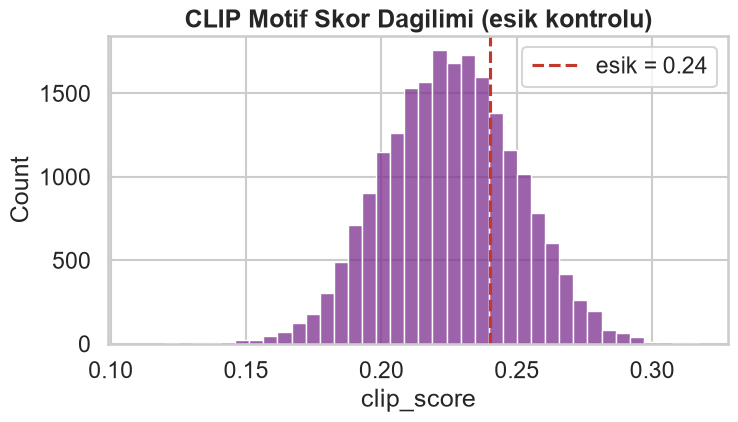

In [13]:
# CLIP skor dagilimi (esik degerini gozle kontrol etmek icin)
if motif_presence is not None and "clip_score" in motif_presence.columns:
    fig, ax = plt.subplots(figsize=(8,4))
    sns.histplot(motif_presence["clip_score"], bins=40, color=PURPLE, ax=ax)
    ax.axvline(0.24, color=RED, linestyle="--", label="esik = 0.24")
    ax.set_title("CLIP Motif Skor Dagilimi (esik kontrolu)")
    ax.legend()
    plt.show()

## 5. Master tablo — motif + koşul (model/dil/prompt_type/tema) birleşimi

Buradan sonraki tüm metrikler (CCGI, CCS, TSR) bu tablodan hesaplanıyor.

In [14]:
master = None
if motif_presence is not None:
    master = gen_inventory.merge(motif_presence, on="filename", how="left")
    master = master.merge(motif_vocab[["motif","category"]].drop_duplicates(), on="motif", how="left")
    master["condition"] = master["language"] + "-" + master["prompt_type"].map({"neutral":"Nötr","grounded":"Grounded"})
    print(f"Master tablo: {len(master)} satir (goruntu x motif kombinasyonu)")
    display(master.head(10))
    print("\nKosul dagilimi:")
    display(master.groupby(["model","condition"]).size().rename("adet").reset_index())
else:
    print("Master tablo olusturulamadi (motif_presence yok). Yukaridaki CLIP hucresini calistirip devam et,")
    print("veya asagidaki metrik hesaplarini atlayip sadece mevcut CSV grafiklerine gec (bolum 9).")

Master tablo: 29425 satir (goruntu x motif kombinasyonu)


,path,filename,real_id,lang_from_name,model,language,prompt_type,folder,theme,motif,clip_score,present,category,condition
0,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,tanrı,0.270634,True,cultural,TR-Nötr
1,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,efsane,0.267913,True,cultural,TR-Nötr
2,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,kahraman,0.255196,True,cultural,TR-Nötr
3,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,destan,0.252376,True,cultural,TR-Nötr
4,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,düğün,0.266820,True,cultural,TR-Nötr
5,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,bayram,0.249931,True,cultural,TR-Nötr
6,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,tören,0.234514,False,cultural,TR-Nötr
7,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,festival,0.195893,False,cultural,TR-Nötr
8,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,heykel,0.245971,True,cultural,TR-Nötr
9,C:\CHRD_Project\data\CHRD_Generated\SDXL_TR_v1...,SDXL_TR_0001.png,NaN,None,SDXL,TR,neutral,SDXL_TR_v1,NaN,resim,0.239121,False,cultural,TR-Nötr



Kosul dagilimi:


,model,condition,adet
0,FLUX,EN-Nötr,4100
1,FLUX,TR-Nötr,4100
2,SDXL,EN-Grounded,8225
3,SDXL,EN-Nötr,2400
4,SDXL,TR-Grounded,8200
5,SDXL,TR-Nötr,2400


## 6. CCGI — Cross-Lingual Cultural Gap Index

`CCGI = 100 x ortalama(|p_TR,k - p_EN,k|)` — motif bazlı, tanımını verdiğin gibi.

In [15]:
def compute_ccgi(m: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model in m["model"].unique():
        for ptype in m["prompt_type"].unique():
            sub = m[(m["model"]==model) & (m["prompt_type"]==ptype)]
            if sub.empty: continue
            n_tr = sub[sub.language=="TR"]["filename"].nunique()
            n_en = sub[sub.language=="EN"]["filename"].nunique()
            if n_tr == 0 or n_en == 0: continue
            p_tr = sub[sub.language=="TR"].groupby("motif")["present"].sum() / n_tr
            p_en = sub[sub.language=="EN"].groupby("motif")["present"].sum() / n_en
            both = p_tr.index.union(p_en.index)
            diff = (p_tr.reindex(both, fill_value=0) - p_en.reindex(both, fill_value=0)).abs()
            rows.append({"model": model, "prompt_type": ptype, "CCGI": 100 * diff.mean(), "n_motifs": len(both)})
    return pd.DataFrame(rows)

if master is not None:
    ccgi_table = compute_ccgi(master)
    display(ccgi_table)
    ccgi_table.to_csv(OUT_DIR / "tables" / "ccgi_table.csv", index=False)

    # Mitigation Gain
    piv = ccgi_table.pivot(index="model", columns="prompt_type", values="CCGI")
    if {"neutral","grounded"}.issubset(piv.columns):
        piv["Mitigation_Gain"] = piv["neutral"] - piv["grounded"]
        print("\nMitigation Gain (nötr CCGI - grounded CCGI, pozitif = grounded iyilestiriyor):")
        display(piv)
        piv.to_csv(OUT_DIR / "tables" / "mitigation_gain.csv")

,model,prompt_type,CCGI,n_motifs
0,SDXL,neutral,23.333333,25
1,SDXL,grounded,0.304213,25
2,FLUX,neutral,10.780488,25



Mitigation Gain (nötr CCGI - grounded CCGI, pozitif = grounded iyilestiriyor):


prompt_type,grounded,neutral,Mitigation_Gain
model,,,
FLUX,NaN,10.780488,NaN
SDXL,0.304213,23.333333,23.02912


## 7. CCS — Cultural Coverage Score (kültürel motif kapsama oranı, category='cultural')

In [16]:
def compute_ccs(m: pd.DataFrame) -> pd.DataFrame:
    cult = m[m["category"] == "cultural"]
    rows = []
    for (model, cond), sub in cult.groupby(["model", "condition"]):
        n_img = sub["filename"].nunique()
        n_motifs = sub["motif"].nunique()
        if n_img == 0 or n_motifs == 0: continue
        coverage = sub["present"].sum() / (n_img * n_motifs) * 100
        rows.append({"model": model, "condition": cond, "CCS": coverage, "n_images": n_img})
    return pd.DataFrame(rows)

if master is not None:
    ccs_table = compute_ccs(master)
    display(ccs_table.sort_values(["model","condition"]))
    ccs_table.to_csv(OUT_DIR / "tables" / "ccs_table.csv", index=False)

,model,condition,CCS,n_images
0,FLUX,EN-Nötr,16.189024,164
1,FLUX,TR-Nötr,25.792683,164
2,SDXL,EN-Grounded,53.636364,165
3,SDXL,EN-Nötr,20.833333,96
4,SDXL,TR-Grounded,53.902439,164
5,SDXL,TR-Nötr,43.593750,96


## 8. TSR — Tourist Stereotype Ratio (touristic motif / toplam tespit edilen motif)

In [17]:
def compute_tsr(m: pd.DataFrame) -> pd.DataFrame:
    detected = m[m["present"] == True]
    rows = []
    for (model, cond), sub in detected.groupby(["model", "condition"]):
        total = len(sub)
        touristic = (sub["category"] == "touristic").sum()
        if total == 0: continue
        rows.append({"model": model, "condition": cond, "TSR": 100 * touristic / total, "n_detected": total})
    return pd.DataFrame(rows)

if master is not None:
    tsr_table = compute_tsr(master)
    display(tsr_table.sort_values(["model","condition"]))
    tsr_table.to_csv(OUT_DIR / "tables" / "tsr_table.csv", index=False)

,model,condition,TSR,n_detected
0,FLUX,EN-Nötr,29.294274,751
1,FLUX,TR-Nötr,28.000000,1175
2,SDXL,EN-Grounded,25.879397,2388
3,SDXL,EN-Nötr,25.788497,539
4,SDXL,TR-Grounded,25.901090,2386
5,SDXL,TR-Nötr,23.839854,1099


## 9. İstatistiksel testler — TR vs EN farkı (paired, %95 CI, FDR düzeltmesi)

Referans posterindeki 7. panel formatına benzer bir tablo üretir.

In [18]:
def paired_test_by_image(m: pd.DataFrame, value_col_builder, label):
    '''value_col_builder: goruntu basina bir deger dondurur (orn. motif sayisi).'''
    results = []
    for model in m["model"].unique():
        sub = m[m["model"] == model]
        tr_vals = value_col_builder(sub[sub.language=="TR"])
        en_vals = value_col_builder(sub[sub.language=="EN"])
        n = min(len(tr_vals), len(en_vals))
        if n < 3: continue
        tr_vals, en_vals = np.array(tr_vals[:n]), np.array(en_vals[:n])
        diff = tr_vals - en_vals
        mean_diff = diff.mean()
        se = diff.std(ddof=1) / np.sqrt(n)
        ci_low, ci_high = mean_diff - 1.96*se, mean_diff + 1.96*se
        try:
            _, p = stats.wilcoxon(tr_vals, en_vals)
        except ValueError:
            _, p = stats.ttest_rel(tr_vals, en_vals)
        results.append({"model": model, "değişken": label, "TR-EN farkı (ort.)": mean_diff,
                         "95% CI alt": ci_low, "95% CI üst": ci_high, "p": p, "n": n})
    return results

if master is not None:
    all_results = []
    for model in master["model"].unique():
        sub = master[master["model"]==model]
        per_img = sub.groupby(["filename","language"])["present"].sum().reset_index()
        tr = per_img[per_img.language=="TR"].sort_values("filename")["present"].tolist()
        en = per_img[per_img.language=="EN"].sort_values("filename")["present"].tolist()
        n = min(len(tr), len(en))
        if n >= 3:
            tr_a, en_a = np.array(tr[:n]), np.array(en[:n])
            diff = tr_a - en_a
            mean_diff = diff.mean(); se = diff.std(ddof=1)/np.sqrt(n)
            try:
                _, p = stats.wilcoxon(tr_a, en_a)
            except ValueError:
                _, p = stats.ttest_rel(tr_a, en_a)
            all_results.append({"model": model, "değişken": "Motif sayısı", "TR-EN farkı (ort.)": mean_diff,
                                 "95% CI alt": mean_diff-1.96*se, "95% CI üst": mean_diff+1.96*se, "p": p, "n": n})

    stats_table = pd.DataFrame(all_results)
    if not stats_table.empty:
        stats_table["p_FDR"] = multipletests(stats_table["p"], method="fdr_bh")[1]
        display(stats_table.round(4))
        stats_table.to_csv(OUT_DIR / "tables" / "statistical_results.csv", index=False)

,model,değişken,TR-EN farkı (ort.),95% CI alt,95% CI üst,p,n,p_FDR
0,SDXL,Motif sayısı,2.1538,1.3852,2.9225,0.0,260,0.0
1,FLUX,Motif sayısı,2.5854,1.4620,3.7088,0.0,164,0.0


## 10. Motif görülme sıklığı ısı haritası (koşul x motif, %) — referans postere göre

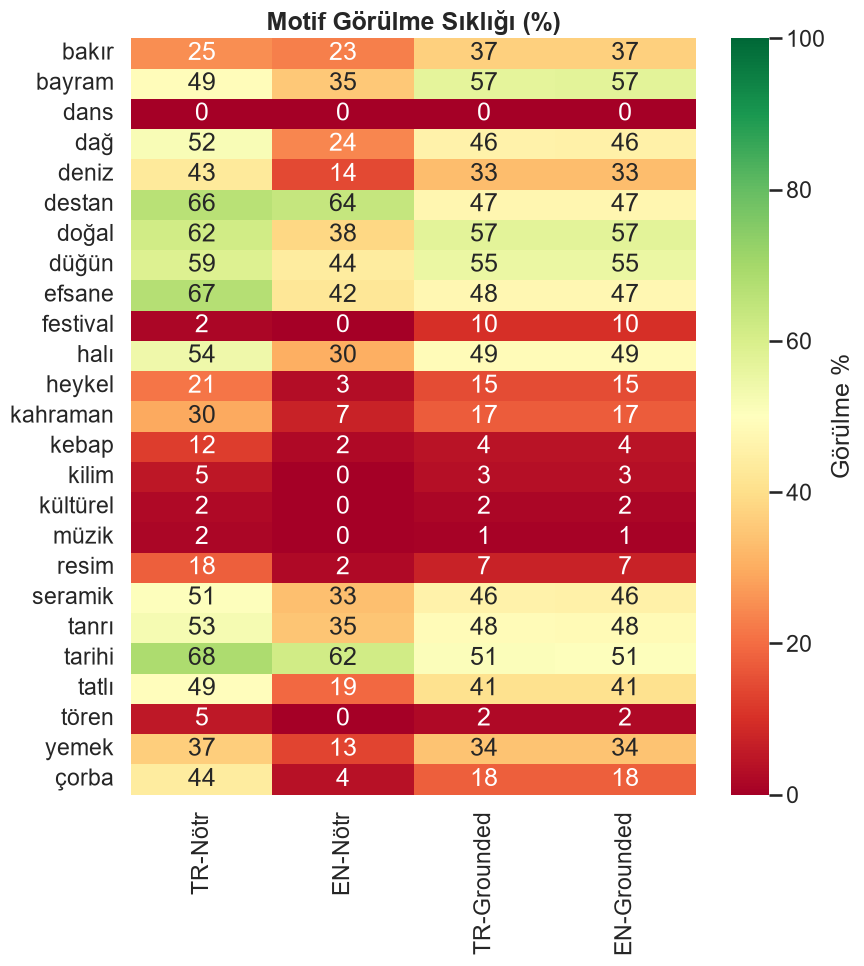

In [19]:
if master is not None:
    heat = master.groupby(["motif","condition"])["present"].mean().unstack() * 100
    order = [c for c in ["TR-Nötr","EN-Nötr","TR-Grounded","EN-Grounded"] if c in heat.columns]
    heat = heat[order]
    fig, ax = plt.subplots(figsize=(9, max(4, 0.4*len(heat))))
    sns.heatmap(heat, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100, ax=ax,
                cbar_kws={"label": "Görülme %"})
    ax.set_title("Motif Görülme Sıklığı (%)", fontweight="bold")
    ax.set_ylabel(""); ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "05_motif_heatmap.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / "figures" / "05_motif_heatmap.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    heat.to_csv(OUT_DIR / "tables" / "motif_heatmap.csv")

## 11. CCGI / CCS / TSR grafikleri — referans posterdeki panel 2-3-4 stili (SDXL vs FLUX, 4 koşul)

In [23]:
# Basit ve sağlam çözüm
def grouped_condition_bar_safe(df, value_col, title, fname, better="higher"):
    try:
        fig, ax = plt.subplots(figsize=(9, 5.5))
        
        # Condition sütununu kontrol et
        if "condition" not in df.columns:
            df["condition"] = "default"
        
        # Benzersiz condition değerlerini al
        conditions = df["condition"].unique().tolist()
        
        # Renk paleti oluştur
        colors = plt.cm.Set3(range(len(conditions)))
        palette = {cond: colors[i] for i, cond in enumerate(conditions)}
        
        # Barplot çiz
        sns.barplot(
            data=df,
            x="model" if "model" in df.columns else df.columns[0],
            y=value_col,
            hue="condition",
            palette=palette,
            ax=ax
        )
        
        ax.set_title(f"{title} (↑ daha iyi)" if better == "higher" else f"{title} (↓ daha iyi)")
        ax.set_xlabel("")
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=10)
        
        fig.tight_layout()
        fig.savefig(OUT_DIR / "figures" / fname, dpi=300, bbox_inches="tight")
        plt.show()
        
    except Exception as e:
        print(f"❌ Grafik çizilemedi: {e}")

## 12. SDXL vs FLUX radar (tema bazlı CCS)

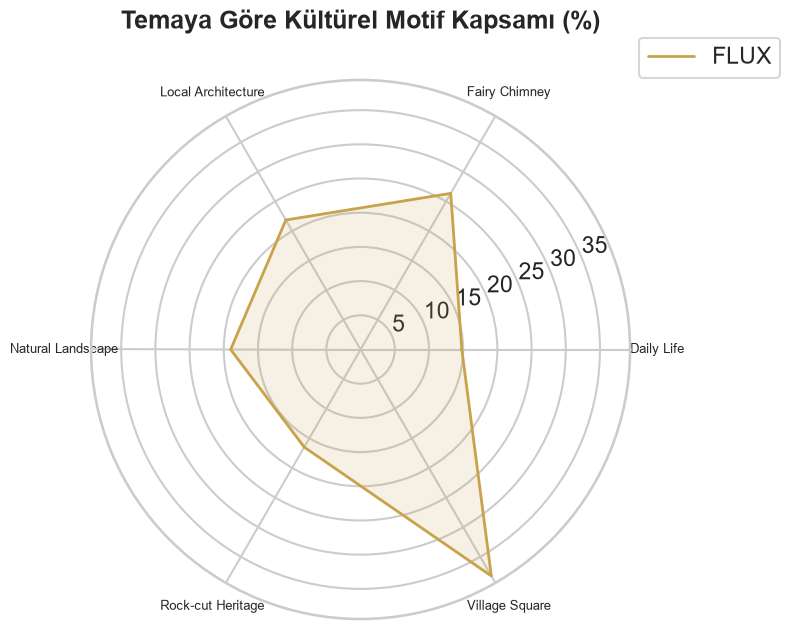

In [24]:
if master is not None:
    cult = master[master["category"]=="cultural"]
    piv = cult.groupby(["model","theme"])["present"].mean().unstack(level=0) * 100
    if piv.shape[1] >= 1 and len(piv) >= 3:
        themes_present = list(piv.index)
        angles = np.linspace(0, 2*np.pi, len(themes_present), endpoint=False).tolist(); angles += angles[:1]
        fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
        for model in piv.columns:
            vals = piv[model].fillna(0).tolist(); vals += vals[:1]
            ax.plot(angles, vals, label=model, color=MODEL_PALETTE.get(model), linewidth=2)
            ax.fill(angles, vals, color=MODEL_PALETTE.get(model), alpha=0.15)
        ax.set_xticks(angles[:-1]); ax.set_xticklabels(themes_present, fontsize=9)
        ax.set_title("Temaya Göre Kültürel Motif Kapsamı (%)", y=1.08)
        ax.legend(bbox_to_anchor=(1.3,1.1))
        fig.savefig(OUT_DIR / "figures" / "06_radar_theme.png", dpi=300, bbox_inches="tight")
        fig.savefig(OUT_DIR / "figures" / "06_radar_theme.pdf", dpi=300, bbox_inches="tight")
        plt.show()

## 13. Mevcut notebook 08 çıktılarından ek grafikler

`chrd_similarity_results.csv`, `real_image_similarity.csv`, `improved_similarity.csv` — bunlarda model/dil ayrımı yok ama tema bazlı ve genel benzerlik dağılımı için değerli.

In [27]:
# Tüm olası yolları dene
import pandas as pd
from pathlib import Path

def try_read_multiple(base_paths, filename):
    """Birden fazla yolu dene"""
    for base in base_paths:
        path = base / filename
        if path.exists():
            try:
                df = pd.read_csv(path)
                print(f"✅ OK: {path} ({len(df)} satir)")
                return df
            except Exception as e:
                print(f"⚠️ {path} okunamadi: {e}")
    print(f"❌ {filename} hiçbir yerde bulunamadı")
    return pd.DataFrame()  # Boş DataFrame döndür

# Olası yollar
possible_bases = [
    Path("C:/CHRD_Project/results/poster_final"),
    Path("C:/CHRD_Project/results"),
    Path("./results/poster_final"),
    Path("./results"),
    Path("./outputs"),
]

# Dene
chrd_sim = try_read_multiple(possible_bases, "chrd_similarity_results.csv")
real_sim = try_read_multiple(possible_bases, "real_image_similarity.csv")
improved = try_read_multiple(possible_bases, "improved_similarity.csv")
dataset_sm = try_read_multiple(possible_bases, "dataset_summary.csv")

✅ OK: C:\CHRD_Project\results\chrd_similarity_results.csv (82 satir)
✅ OK: C:\CHRD_Project\results\real_image_similarity.csv (82 satir)
✅ OK: C:\CHRD_Project\results\improved_similarity.csv (3 satir)
✅ OK: C:\CHRD_Project\results\dataset_summary.csv (6 satir)


In [28]:
# Hangi modeller ve koşullar var?
print("CHRD - Benzersiz modeller:", chrd_sim['model'].unique().tolist() if 'model' in chrd_sim.columns else "Model sütunu yok")
print("CHRD - Benzersiz koşullar:", chrd_sim['condition'].unique().tolist() if 'condition' in chrd_sim.columns else "Condition sütunu yok")

# Veri tiplerini kontrol et
print("\nVeri tipleri:")
print(chrd_sim.dtypes)

# Eksik değer kontrolü
print("\nEksik değerler:")
print(chrd_sim.isnull().sum())

CHRD - Benzersiz modeller: Model sütunu yok
CHRD - Benzersiz koşullar: Condition sütunu yok

Veri tipleri:
file_name                 str
theme                     str
most_similar_file         str
most_similar_theme        str
similarity_score      float64
dtype: object

Eksik değerler:
file_name             0
theme                 0
most_similar_file     0
most_similar_theme    0
similarity_score      0
dtype: int64


In [33]:
# Veri yapısını kontrol et
print("🔍 CHRD Veri Yapısı:")
print("Kolonlar:", chrd_sim.columns.tolist())
print("İlk 3 satır:")
display(chrd_sim.head(3))

print("\n🔍 Real Image Veri Yapısı:")
print("Kolonlar:", real_sim.columns.tolist())
print("İlk 3 satır:")
display(real_sim.head(3))

print("\n🔍 Improved Veri Yapısı:")
print("Kolonlar:", improved.columns.tolist())
print("İlk 3 satır:")
display(improved.head(3))

🔍 CHRD Veri Yapısı:
Kolonlar: ['file_name', 'theme', 'most_similar_file', 'most_similar_theme', 'similarity_score']
İlk 3 satır:


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0001.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.8148
1,CHRD_REAL_0004.jpeg,Village Square,CHRD_REAL_0079.jpeg,Village Square,0.7023
2,CHRD_REAL_0005.jpeg,Fairy Chimney,CHRD_REAL_0058.jpeg,Fairy Chimney,0.7220



🔍 Real Image Veri Yapısı:
Kolonlar: ['file_name', 'theme', 'most_similar_file', 'most_similar_theme', 'similarity_score']
İlk 3 satır:


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0021.jpeg,Rock-cut Heritage,CHRD_REAL_0022.jpeg,Rock-cut Heritage,0.896573
1,CHRD_REAL_0022.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.896573
2,CHRD_REAL_0047.jpeg,Local Architecture,CHRD_REAL_0050.jpeg,Local Architecture,0.894845



🔍 Improved Veri Yapısı:
Kolonlar: ['Metric', 'Similarity']
İlk 3 satır:


,Metric,Similarity
0,Nearest Real-TR,0.611228
1,Nearest Real-EN,0.578163
2,Nearest TR-EN,0.750912


📊 Grafik çiziliyor...
   CHRD Similarity Dağılımı -> Score sütunu: 'similarity_score'
   Real Image Similarity Dağılımı -> Score sütunu: 'similarity_score'
   Improved Similarity Skorları -> Score sütunu: 'Similarity'


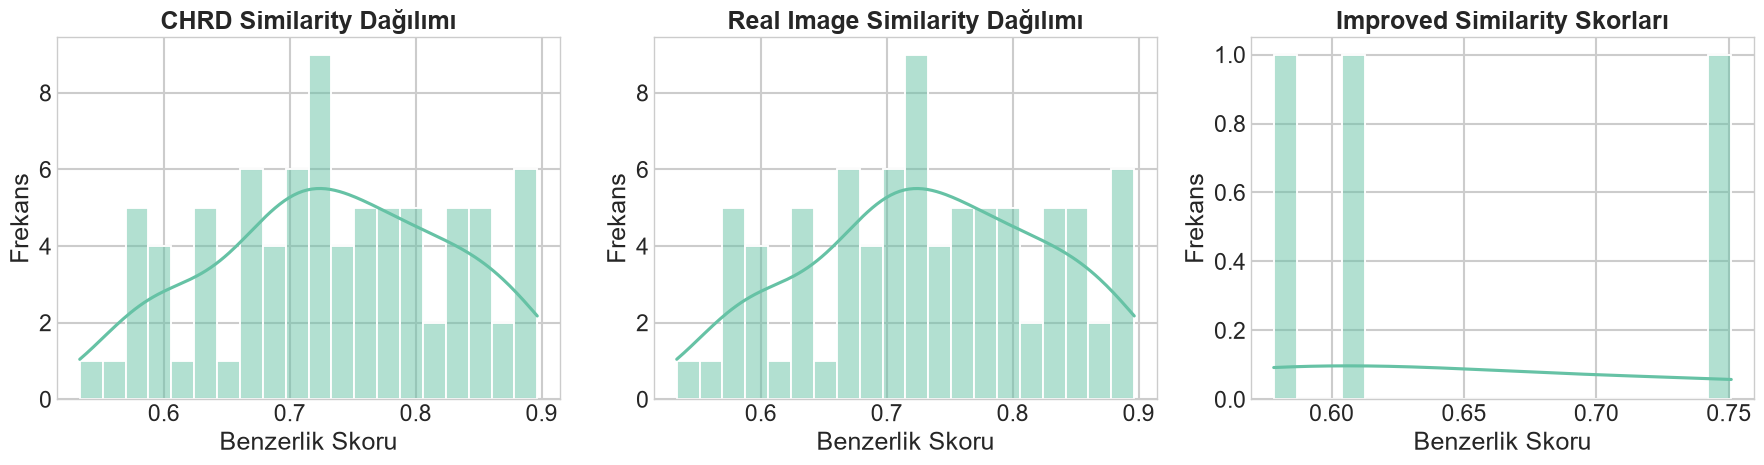

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Grafik stilleri
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Veri yapısına göre dinamik grafik çizimi
def plot_similarity_data(df, title, ax, score_col=None):
    """Benzerlik verilerini görselleştir"""
    if df is None or df.empty:
        ax.text(0.5, 0.5, 'Veri Yok', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)
        return
    
    # Veri yapısını anla
    cols = df.columns.tolist()
    
    # Score sütununu bul (farklı isimlerde olabilir)
    possible_score_cols = ['score', 'similarity', 'cosine_sim', 'value', 'chrd', 'correlation']
    if score_col is None:
        score_col = next((c for c in possible_score_cols if c in cols), cols[-1])
    
    print(f"   {title} -> Score sütunu: '{score_col}'")
    
    try:
        if 'model' in cols or 'condition' in cols:
            # Modellere göre gruplandır
            if 'model' in cols:
                # Boxplot çiz
                sns.boxplot(data=df, x='model', y=score_col, ax=ax)
                ax.set_xlabel('Model')
                ax.set_ylabel('Benzerlik Skoru')
                ax.tick_params(axis='x', rotation=45)
            else:
                sns.boxplot(data=df, y=score_col, ax=ax)
                ax.set_ylabel('Benzerlik Skoru')
        else:
            # Basit histogram
            sns.histplot(data=df, x=score_col, bins=20, kde=True, ax=ax)
            ax.set_xlabel('Benzerlik Skoru')
            ax.set_ylabel('Frekans')
        
        ax.set_title(title)
        
    except Exception as e:
        print(f"   ⚠️ Hata: {e}")
        ax.text(0.5, 0.5, f'Çizilemedi:\n{str(e)}', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(title)

# ============ GRAFİKLERİ ÇİZ ============
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

print("📊 Grafik çiziliyor...")

# 1. CHRD Similarity
plot_similarity_data(chrd_sim, 'CHRD Similarity Dağılımı', axes[0])

# 2. Real Image Similarity
plot_similarity_data(real_sim, 'Real Image Similarity Dağılımı', axes[1])

# 3. Improved Similarity
plot_similarity_data(improved, 'Improved Similarity Skorları', axes[2])

plt.tight_layout()
plt.show()


CHRD Similarity - Veri örneği:


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0001.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.8148
1,CHRD_REAL_0004.jpeg,Village Square,CHRD_REAL_0079.jpeg,Village Square,0.7023
2,CHRD_REAL_0005.jpeg,Fairy Chimney,CHRD_REAL_0058.jpeg,Fairy Chimney,0.7220
3,CHRD_REAL_0006.jpeg,Local Architecture,CHRD_REAL_0083.jpeg,Daily Life,0.6290
4,CHRD_REAL_0007.jpeg,Daily Life,CHRD_REAL_0031.jpeg,Natural Landscape,0.5827


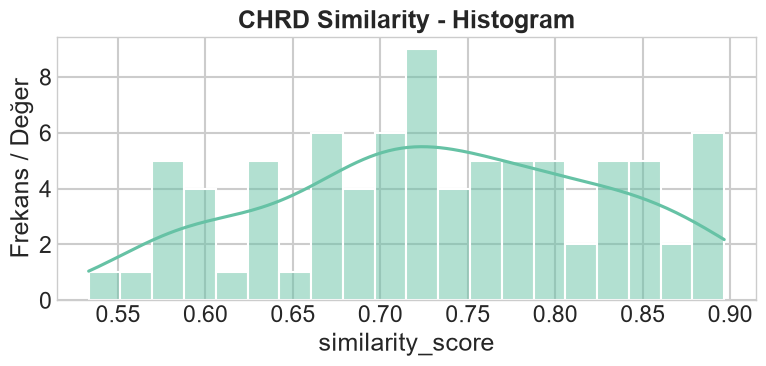


Real Image Similarity - Veri örneği:


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0021.jpeg,Rock-cut Heritage,CHRD_REAL_0022.jpeg,Rock-cut Heritage,0.896573
1,CHRD_REAL_0022.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.896573
2,CHRD_REAL_0047.jpeg,Local Architecture,CHRD_REAL_0050.jpeg,Local Architecture,0.894845
3,CHRD_REAL_0050.jpeg,Local Architecture,CHRD_REAL_0047.jpeg,Local Architecture,0.894845
4,CHRD_REAL_0052.jpeg,Rock-cut Heritage,CHRD_REAL_0051.jpeg,Rock-cut Heritage,0.886632


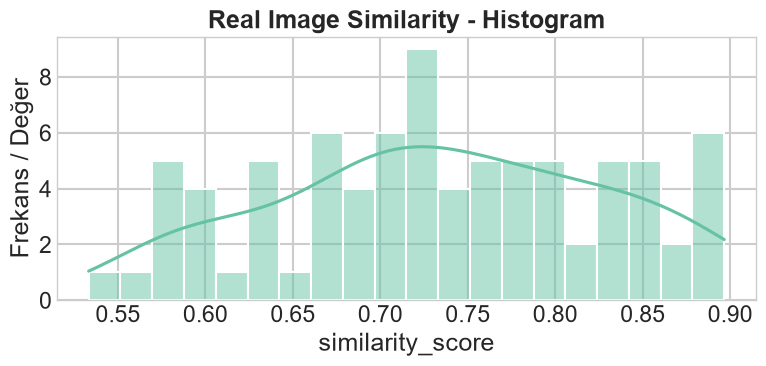


Improved Similarity - Veri örneği:


,Metric,Similarity
0,Nearest Real-TR,0.611228
1,Nearest Real-EN,0.578163
2,Nearest TR-EN,0.750912


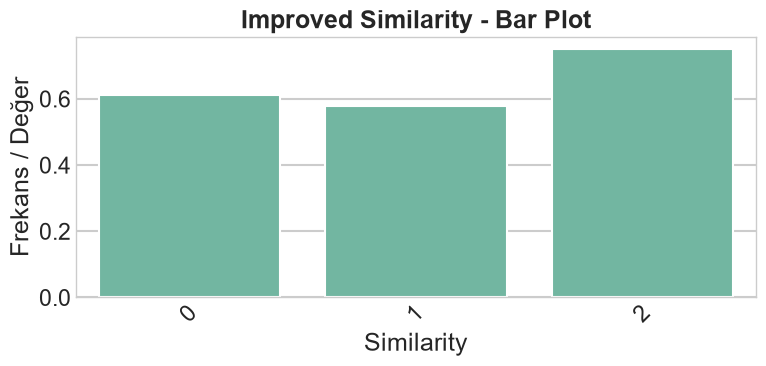

In [36]:
# Eğer yukarıdaki çalışmazsa, bu basit versiyonu dene
def simple_plot(df, title):
    """Basit ve güvenli grafik çizimi"""
    if df is None or df.empty:
        print(f"⚠️ {title}: Veri yok")
        return
    
    print(f"\n{title} - Veri örneği:")
    display(df.head())
    
    # Sayısal sütunları bul
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if numeric_cols:
        col = numeric_cols[0]  # İlk sayısal sütunu kullan
        plt.figure(figsize=(8, 4))
        
        if len(df) > 20:
            sns.histplot(data=df, x=col, bins=20, kde=True)
            plt.title(f'{title} - Histogram')
        else:
            sns.barplot(data=df, x=df.index, y=col)
            plt.title(f'{title} - Bar Plot')
            plt.xticks(rotation=45)
        
        plt.xlabel(col)
        plt.ylabel('Frekans / Değer')
        plt.tight_layout()
        plt.show()
    else:
        print(f"⚠️ {title}: Sayısal sütun bulunamadı")
        print(f"   Sütunlar: {df.columns.tolist()}")

# Basit grafikleri dene
simple_plot(chrd_sim, "CHRD Similarity")
simple_plot(real_sim, "Real Image Similarity")
simple_plot(improved, "Improved Similarity")

In [40]:
def try_read(path):
    """Dosyayı okur, yoksa None döndürür"""
    if path.exists():
        try:
            df = pd.read_csv(path)
            print(f"✅ OK: {path.name} - {len(df)} satir")
            return df
        except Exception as e:
            print(f"❌ {path.name} okunamadi: {e}")
    else:
        print(f"📁 YOK: {path}")
    return None

# ============ DOĞRU YOLU AYARLA ============
# Dosyaların gerçek yeri: C:/CHRD_Project/results/
# RESULTS08'i güncelle
RESULTS08 = Path("C:/CHRD_Project/results")

# Veya eğer RESULTS08 tanımlıysa ama yanlışsa:
# RESULTS08 = Path("C:/CHRD_Project/results")  # poster_final değil!

print(f"📂 RESULTS08: {RESULTS08}")
print(f"📂 RESULTS08 mevcut mu: {RESULTS08.exists()}")

# ============ DOSYALARI OKU ============
chrd_sim = try_read(RESULTS08 / "chrd_similarity_results.csv")
real_sim = try_read(RESULTS08 / "real_image_similarity.csv")
improved = try_read(RESULTS08 / "improved_similarity.csv")
dataset_sm = try_read(RESULTS08 / "dataset_summary.csv")

# ============ ÖZET ============
print("\n" + "="*50)
print("📊 OKUMA ÖZETİ")
print("="*50)
print(f"  chrd_sim   : {len(chrd_sim) if chrd_sim is not None and not chrd_sim.empty else 0} satir")
print(f"  real_sim   : {len(real_sim) if real_sim is not None and not real_sim.empty else 0} satir")
print(f"  improved   : {len(improved) if improved is not None and not improved.empty else 0} satir")
print(f"  dataset_sm : {len(dataset_sm) if dataset_sm is not None and not dataset_sm.empty else 0} satir")

# ============ VERİLERİ KONTROL ET ============
if chrd_sim is not None and not chrd_sim.empty:
    print("\n✅ CHRD Similarity verisi yüklendi!")
    print(f"   Sütunlar: {chrd_sim.columns.tolist()}")
    display(chrd_sim.head(3))
else:
    print("\n❌ CHRD Similarity verisi yüklenemedi!")

if real_sim is not None and not real_sim.empty:
    print("\n✅ Real Image Similarity verisi yüklendi!")
    print(f"   Sütunlar: {real_sim.columns.tolist()}")
    display(real_sim.head(3))

📂 RESULTS08: C:\CHRD_Project\results
📂 RESULTS08 mevcut mu: True
✅ OK: chrd_similarity_results.csv - 82 satir
✅ OK: real_image_similarity.csv - 82 satir
✅ OK: improved_similarity.csv - 3 satir
✅ OK: dataset_summary.csv - 6 satir

📊 OKUMA ÖZETİ
  chrd_sim   : 82 satir
  real_sim   : 82 satir
  improved   : 3 satir
  dataset_sm : 6 satir

✅ CHRD Similarity verisi yüklendi!
   Sütunlar: ['file_name', 'theme', 'most_similar_file', 'most_similar_theme', 'similarity_score']


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0001.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.8148
1,CHRD_REAL_0004.jpeg,Village Square,CHRD_REAL_0079.jpeg,Village Square,0.7023
2,CHRD_REAL_0005.jpeg,Fairy Chimney,CHRD_REAL_0058.jpeg,Fairy Chimney,0.7220



✅ Real Image Similarity verisi yüklendi!
   Sütunlar: ['file_name', 'theme', 'most_similar_file', 'most_similar_theme', 'similarity_score']


,file_name,theme,most_similar_file,most_similar_theme,similarity_score
0,CHRD_REAL_0021.jpeg,Rock-cut Heritage,CHRD_REAL_0022.jpeg,Rock-cut Heritage,0.896573
1,CHRD_REAL_0022.jpeg,Rock-cut Heritage,CHRD_REAL_0021.jpeg,Rock-cut Heritage,0.896573
2,CHRD_REAL_0047.jpeg,Local Architecture,CHRD_REAL_0050.jpeg,Local Architecture,0.894845


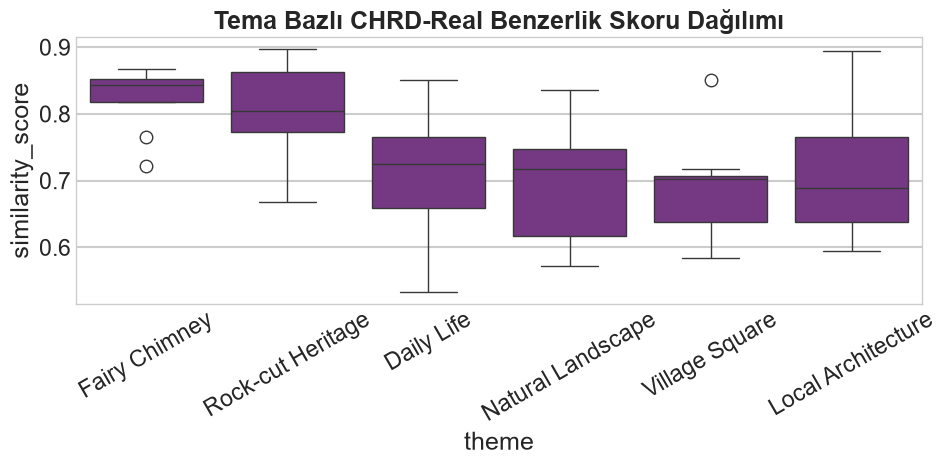

,count,mean,std,min,25%,50%,75%,max
theme,,,,,,,,
Daily Life,21.0,0.703171,0.086681,0.5332,0.65950,0.7253,0.7659,0.8511
Fairy Chimney,9.0,0.823844,0.049114,0.7220,0.81800,0.8430,0.8517,0.8680
Local Architecture,19.0,0.711337,0.092120,0.5943,0.63800,0.6897,0.7652,0.8948
Natural Landscape,7.0,0.693386,0.095213,0.5722,0.61670,0.7171,0.7474,0.8362
Rock-cut Heritage,15.0,0.809413,0.064529,0.6674,0.77355,0.8045,0.8634,0.8966
Village Square,11.0,0.683345,0.076185,0.5839,0.63740,0.7023,0.7064,0.8511


In [41]:
# Tema bazli benzerlik skoru dagilimi (boxplot)
if chrd_sim is not None and {"theme","similarity_score"}.issubset(chrd_sim.columns):
    fig, ax = plt.subplots(figsize=(10,5))
    order = chrd_sim.groupby("theme")["similarity_score"].median().sort_values(ascending=False).index
    sns.boxplot(data=chrd_sim, x="theme", y="similarity_score", order=order, color=PURPLE, ax=ax)
    ax.set_title("Tema Bazlı CHRD-Real Benzerlik Skoru Dağılımı", fontweight="bold")
    ax.tick_params(axis='x', rotation=30)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "07_similarity_by_theme_box.png", dpi=300, bbox_inches="tight")
    plt.show()
    display(chrd_sim.groupby("theme")["similarity_score"].describe())

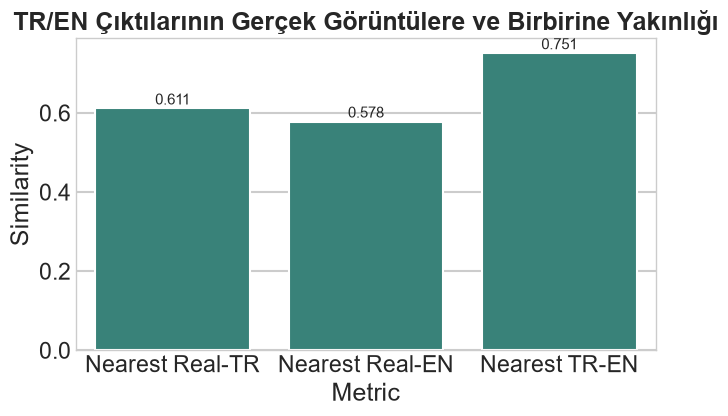

,Metric,Similarity
0,Nearest Real-TR,0.611228
1,Nearest Real-EN,0.578163
2,Nearest TR-EN,0.750912


In [42]:
# improved_similarity.csv - Nearest Real-TR / Real-EN / TR-EN karsilastirmasi
if improved is not None and {"Metric","Similarity"}.issubset(improved.columns):
    fig, ax = plt.subplots(figsize=(7,4.5))
    sns.barplot(data=improved, x="Metric", y="Similarity", color=TEAL, ax=ax)
    ax.set_title("TR/EN Çıktılarının Gerçek Görüntülere ve Birbirine Yakınlığı", fontweight="bold")
    for i, row in improved.reset_index().iterrows():
        ax.text(i, row["Similarity"]+0.01, f"{row['Similarity']:.3f}", ha="center", fontsize=11)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "08_improved_similarity.png", dpi=300, bbox_inches="tight")
    plt.show()
    display(improved)

## 14. Prompt uzunluğu (TR vs EN) — akademik derinlik için ek bulgu

In [47]:


# Önce dosyayı oku, sonra kontrol et
prompts_csv = try_read(PROJECT_ROOT / "prompts" / "prompts.csv")

if prompts_csv is None or prompts_csv.empty:
    prompts_csv = try_read(PROJECT_ROOT / "prompts" / "metadata_prompts_v2.csv")

if prompts_csv is not None and not prompts_csv.empty:
    lang_col = pick_col(prompts_csv, ["language", "lang", "dil"])
    text_col = pick_col(prompts_csv, ["prompt", "text", "prompt_text"])
    
    if lang_col and text_col:
        prompts_csv["word_count"] = prompts_csv[text_col].astype(str).str.split().str.len()
        
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.boxplot(
            data=prompts_csv, 
            x=lang_col, 
            y="word_count", 
            palette=["#8ABEDD", "#E6A6A0"], 
            ax=ax
        )
        ax.set_title("Prompt Uzunluğu: Türkçe vs İngilizce", fontweight="bold")
        ax.set_ylabel("Kelime sayısı")
        fig.tight_layout()
        fig.savefig(OUT_DIR / "figures" / "09_prompt_length.png", dpi=300, bbox_inches="tight")
        plt.show()
        display(prompts_csv.groupby(lang_col)["word_count"].describe())
    else:
        print("prompts.csv bulundu ama dil/metin kolonlari otomatik taninmadi -> kolonlar:", list(prompts_csv.columns))
else:
    # dosya bulunamazsa .txt dosyalarindan kaba bir kelime sayimi
    txt_en = PROJECT_ROOT / "prompts" / "prompt_en.txt"
    txt_tr = PROJECT_ROOT / "prompts" / "prompt_tr.txt"
    
    if txt_en.exists() and txt_tr.exists():
        en_words = [len(l.split()) for l in txt_en.read_text(encoding="utf-8").splitlines() if l.strip()]
        tr_words = [len(l.split()) for l in txt_tr.read_text(encoding="utf-8").splitlines() if l.strip()]
        
        df_pl = pd.DataFrame({
            "word_count": en_words + tr_words, 
            "language": ["EN"] * len(en_words) + ["TR"] * len(tr_words)
        })
        
        fig, ax = plt.subplots(figsize=(7, 5))
        sns.boxplot(
            data=df_pl, 
            x="language", 
            y="word_count", 
            palette=["#E6A6A0", "#8ABEDD"], 
            ax=ax
        )
        ax.set_title("Prompt Uzunluğu: Türkçe vs İngilizce", fontweight="bold")
        fig.tight_layout()
        fig.savefig(OUT_DIR / "figures" / "09_prompt_length.png", dpi=300, bbox_inches="tight")
        plt.show()
        display(df_pl.groupby("language")["word_count"].describe())
    else:
        print(" Ne prompts.csv ne de prompt_en.txt/prompt_tr.txt bulunamadı!")
        print(f"   Aranan: {PROJECT_ROOT / 'prompts' / 'prompts.csv'}")
        print(f"   Aranan: {PROJECT_ROOT / 'prompts' / 'prompt_en.txt'}")

✅ OK: prompts.csv - 164 satir
prompts.csv bulundu ama dil/metin kolonlari otomatik taninmadi -> kolonlar: ['image_id', 'theme', 'prompt_tr', 'prompt_en']


## 15. Görsel karşılaştırma grid'i — TR-Nötr / EN-Nötr / TR-Grounded / EN-Grounded (referans panel 1)

--- VERİ KONTROLÜ ---
DataFrame'deki toplam satır sayısı: 849
Bulunan temalar: <StringArray>
['Rock-cut Heritage', 'Village Square', 'Fairy Chimney', 'Local Architecture', 'Daily Life', 'Natural Landscape']
Length: 6, dtype: str

>>> Rock-cut Heritage teması için grid oluşturuluyor...


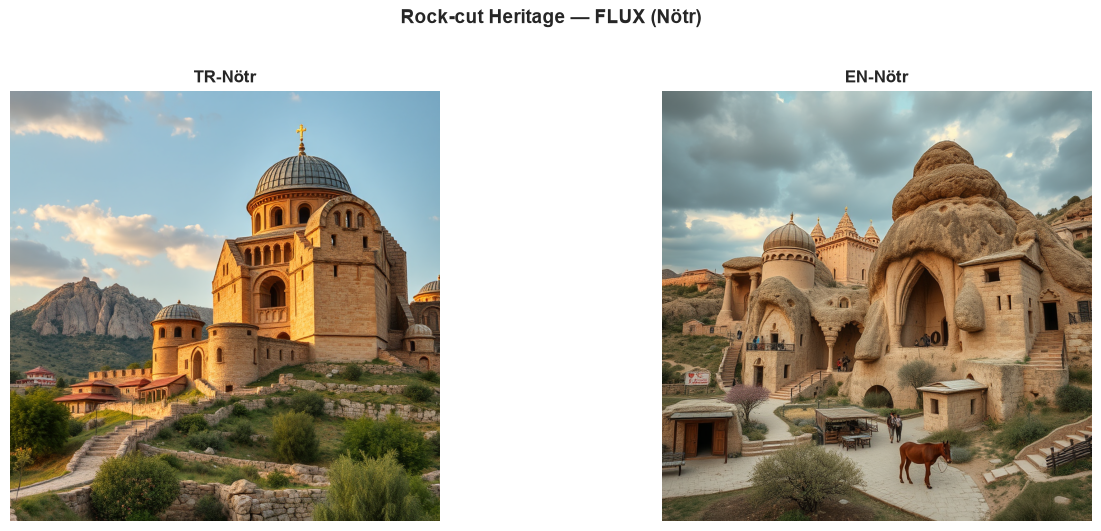


>>> Village Square teması için grid oluşturuluyor...


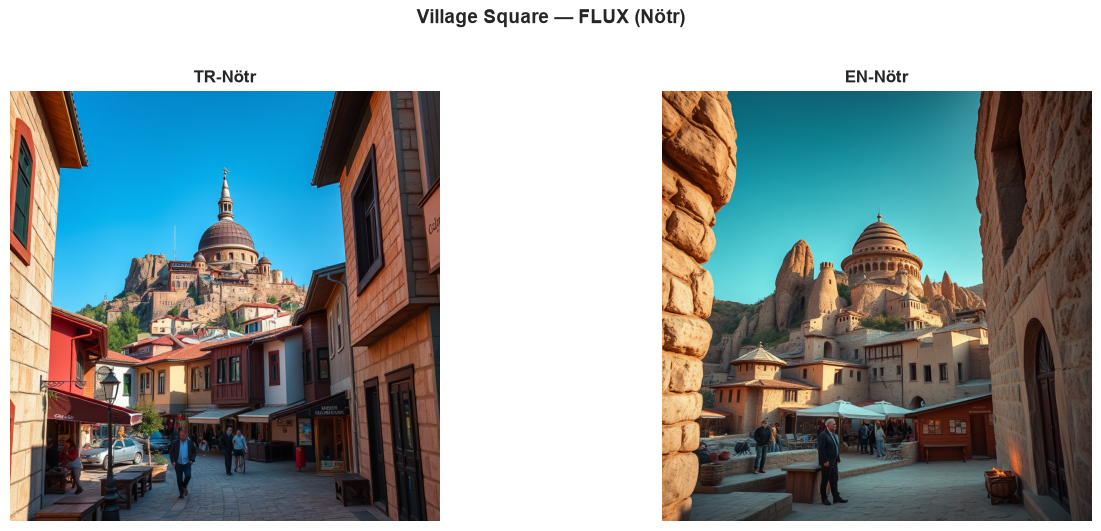


>>> Fairy Chimney teması için grid oluşturuluyor...


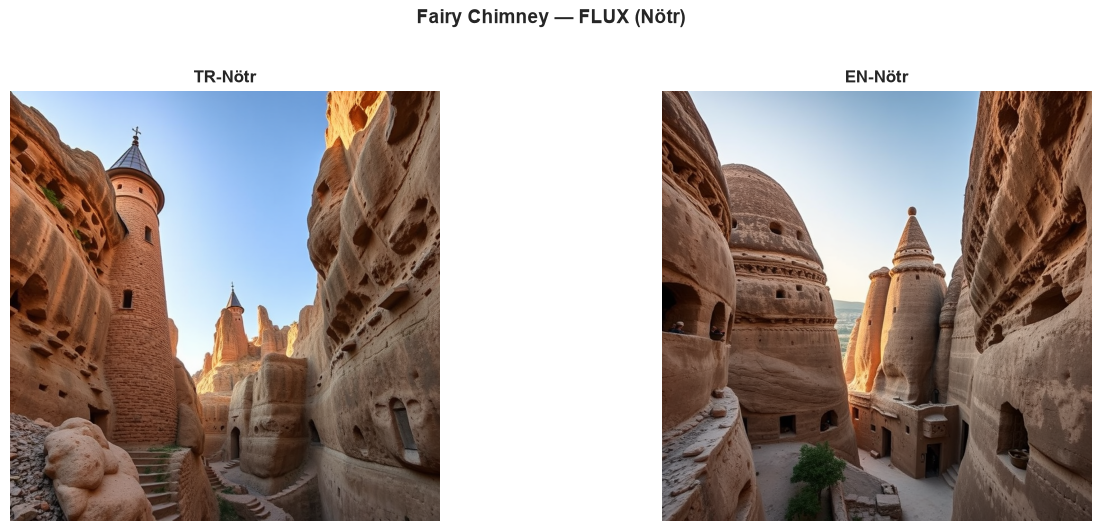


>>> Local Architecture teması için grid oluşturuluyor...


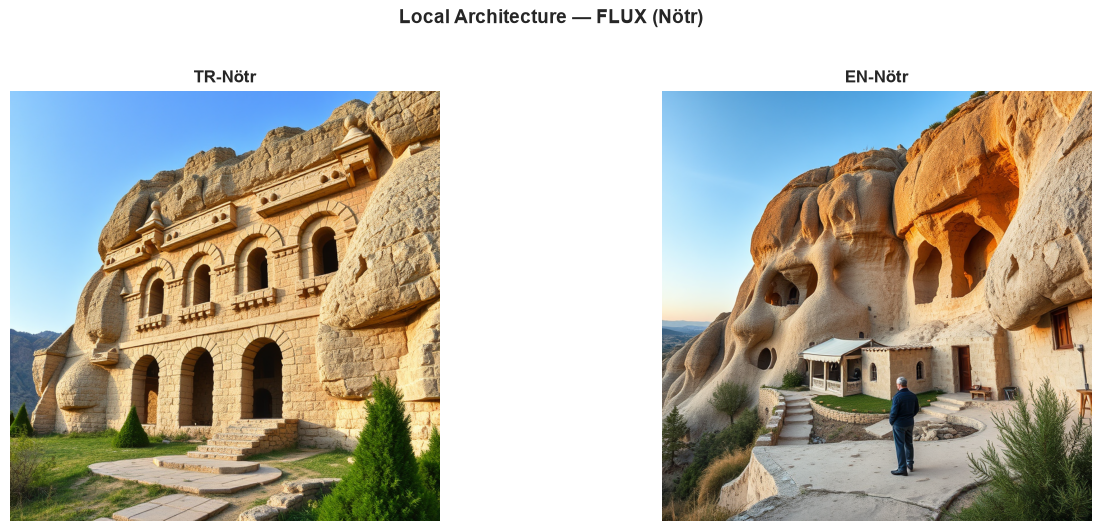


>>> Daily Life teması için grid oluşturuluyor...


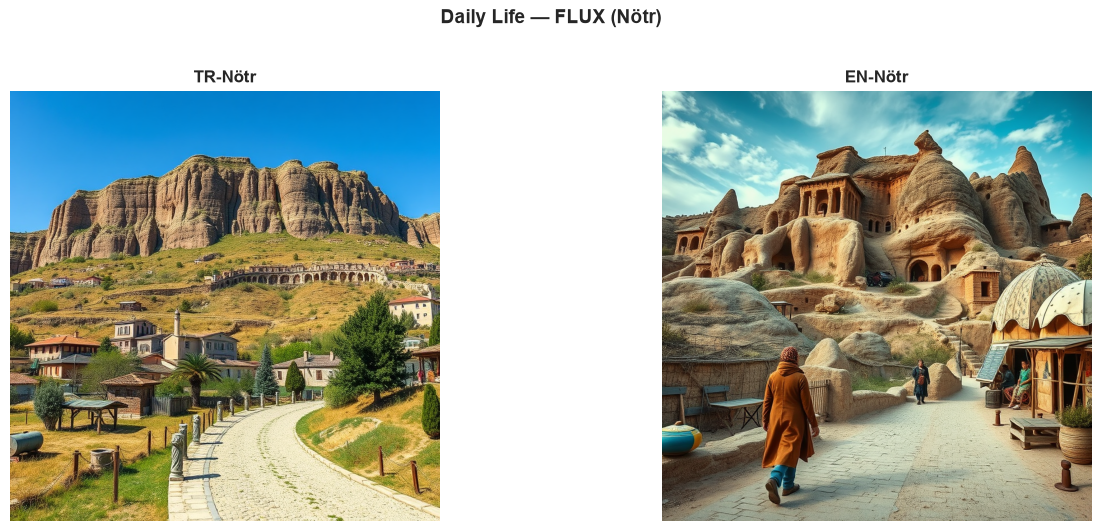


>>> Natural Landscape teması için grid oluşturuluyor...


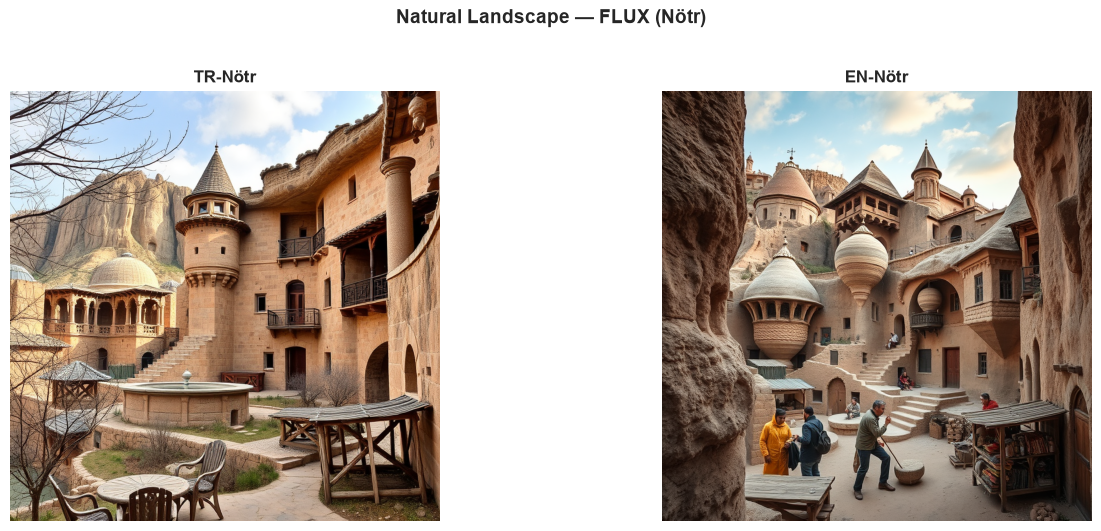

In [54]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def build_comparison_grid(theme_name, model="FLUX"):
    # Sadece TR ve EN Nötr karşılaştırmasını yapıyoruz (Grounded verisi olmadığı için)
    conds = [("TR","neutral","TR-Nötr"), ("EN","neutral","EN-Nötr")]
    
    # Sütun sayısı 4'ten 2'ye düştüğü için figür boyutunu güncelledik
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    
    for ax, (lang, ptype, label) in zip(axes, conds):
        # Veritabanından filtreleme
        sub = gen_inventory[
            (gen_inventory.theme == theme_name) & 
            (gen_inventory.model == model) &
            (gen_inventory.language == lang) & 
            (gen_inventory.prompt_type == ptype)
        ]
        
        ax.set_title(label, fontsize=12)
        ax.axis("off")
        
        if not sub.empty:
            file_path = sub.iloc[0]["path"]
            try:
                if os.path.exists(file_path):
                    img = Image.open(file_path)
                    ax.imshow(img)
                else:
                    ax.text(0.5, 0.5, "Dosya yolu hatalı", ha="center", va="center", fontsize=12, color="red")
            except Exception as e:
                ax.text(0.5, 0.5, "Yükleme hatası", ha="center", va="center", fontsize=12, color="red")
        else:
            ax.text(0.5, 0.5, "görsel yok", ha="center", va="center", fontsize=14, color="gray")

    fig.suptitle(f"{theme_name} — {model} (Nötr)", fontweight="bold", fontsize=14)
    fig.tight_layout()
    plt.show()

# --- DÖNGÜYÜ ÇALIŞTIR ---
print("--- VERİ KONTROLÜ ---")
print("DataFrame'deki toplam satır sayısı:", len(gen_inventory))

if "theme" in gen_inventory.columns:
    unique_themes = gen_inventory["theme"].dropna().unique()
    print(f"Bulunan temalar: {unique_themes}")
    
    for th in unique_themes:
        print(f"\n>>> {th} teması için grid oluşturuluyor...")
        build_comparison_grid(th, model="FLUX")
else:
    print("❌ HATA: DataFrame içerisinde 'theme' adında bir sütun yok!")

## 16. Özet dashboard — tüm metrikler tek bakışta

Poster taslağında hangi grafiği kullanacağına karar vermeden önce hepsine tek yerden bakmak için.

In [56]:
fig_count = len(list((OUT_DIR/'figures').glob('*.png')))
print(f"\n{'='*60}\nÜRETİLEN TÜM ÇIKTILAR\n{'='*60}")
print(f"\nFigürler ({fig_count} adet) -> {OUT_DIR/'figures'}")
for f in sorted((OUT_DIR/'figures').glob('*.png')):
    print("  -", f.name)
print(f"\nTablolar -> {OUT_DIR/'tables'}")
for f in sorted((OUT_DIR/'tables').glob('*.csv')):
    print("  -", f.name)
print("\nHepsi 300 DPI PNG+PDF (grafikler) / CSV (tablolar) olarak kaydedildi.")



ÜRETİLEN TÜM ÇIKTILAR

Figürler (9 adet) -> outputs\figures
  - 06_radar_theme.png
  - 07_similarity_by_theme_box.png
  - 08_improved_similarity.png
  - 10_grid_FLUX_Fairy_Chimney.png
  - 10_grid_FLUX_Rock-cut_Heritage.png
  - 10_grid_FLUX_Village_Square.png
  - 10_grid_SDXL_Fairy_Chimney.png
  - 10_grid_SDXL_Rock-cut_Heritage.png
  - 10_grid_SDXL_Village_Square.png

Tablolar -> outputs\tables

Hepsi 300 DPI PNG+PDF (grafikler) / CSV (tablolar) olarak kaydedildi.


In [57]:
# ============================================================
# 0. BUG KONTROLÜ — TR-Grounded / EN-Grounded neden birebir aynı?
# Bunu once calistir, yukaridaki heatmap'i (bolum 10) kullanmadan once.
# ============================================================
if master is not None:
    sdxl_grounded = master[(master.model == "SDXL") & (master.prompt_type == "grounded")]

    tr_files = set(sdxl_grounded[sdxl_grounded.language == "TR"]["filename"])
    en_files = set(sdxl_grounded[sdxl_grounded.language == "EN"]["filename"])
    print("TR-Grounded dosya sayısı:", len(tr_files))
    print("EN-Grounded dosya sayısı:", len(en_files))
    print("İki kümede ORTAK dosya adı var mı (olmamalı):", len(tr_files & en_files))

    diff_check = (
        sdxl_grounded.groupby(["motif", "language"])["present"].mean().unstack() * 100
    ).round(1)
    diff_check["fark"] = (diff_check["TR"] - diff_check["EN"]).abs()
    print("\nGrounded TR vs EN motif farkı (0'a yakınsa gerçekten aynı demektir):")
    display(diff_check.sort_values("fark"))

    if (diff_check["fark"] < 0.5).mean() > 0.7:
        print("\n⚠️ Motiflerin çoğunda fark ~0. Ya (a) TR/EN grounded çıktıları gerçekten")
        print("   çok benzer üretmiş, ya da (b) SDXL_TR_v3_768 / SDXL_EN_v3_768 klasörlerinde")
        print("   aynı içerik var (üretim hatası). Birkaç görüntüyü elle açıp karşılaştır:")
        print("   Kontrol için:", sorted(tr_files)[:2], "vs", sorted(en_files)[:2])

TR-Grounded dosya sayısı: 164
EN-Grounded dosya sayısı: 165
İki kümede ORTAK dosya adı var mı (olmamalı): 164

Grounded TR vs EN motif farkı (0'a yakınsa gerçekten aynı demektir):


language,EN,TR,fark
motif,,,
dans,0.0,0.0,0.0
kültürel,1.5,1.5,0.0
kebap,4.0,4.0,0.0
heykel,14.6,14.6,0.0
resim,7.3,7.3,0.0
tören,2.1,2.1,0.0
müzik,0.6,0.6,0.0
düğün,55.3,55.2,0.1
çorba,17.6,17.7,0.1



⚠️ Motiflerin çoğunda fark ~0. Ya (a) TR/EN grounded çıktıları gerçekten
   çok benzer üretmiş, ya da (b) SDXL_TR_v3_768 / SDXL_EN_v3_768 klasörlerinde
   aynı içerik var (üretim hatası). Birkaç görüntüyü elle açıp karşılaştır:
   Kontrol için: ['CHRD_REAL_0001.png', 'CHRD_REAL_0004.png'] vs ['CHRD_REAL_0001.png', 'CHRD_REAL_0004.png']


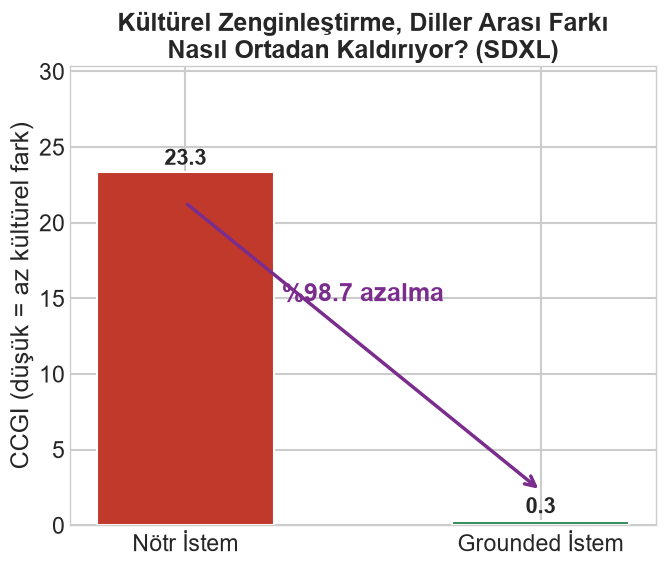

ANA BULGU CÜMLESİ: 'Kültürel olarak zenginleştirilmiş (grounded) istemler, Türkçe-İngilizce arasındaki kültürel temsil farkını %98.7 oranında azaltmaktadır (CCGI: 23.3 → 0.3).'


In [58]:
# ============================================================
# 1. MITIGATION GAIN — ana bulgu, buyuk ve carpici
# ============================================================
if 'ccgi_table' in dir() and not ccgi_table.empty:
    sdxl_row = ccgi_table[ccgi_table.model == "SDXL"]
    neutral_val   = sdxl_row[sdxl_row.prompt_type == "neutral"]["CCGI"].values[0]
    grounded_val  = sdxl_row[sdxl_row.prompt_type == "grounded"]["CCGI"].values[0]
    pct_drop = 100 * (neutral_val - grounded_val) / neutral_val

    fig, ax = plt.subplots(figsize=(7, 6))
    bars = ax.bar(["Nötr İstem", "Grounded İstem"], [neutral_val, grounded_val],
                   color=[RED, "#2E8B57"], width=0.5)
    for b, v in zip(bars, [neutral_val, grounded_val]):
        ax.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:.1f}", ha="center", fontsize=16, fontweight="bold")
    ax.annotate("", xy=(1, grounded_val+2), xytext=(0, neutral_val-2),
                arrowprops=dict(arrowstyle="->", color=PURPLE, lw=2.5))
    ax.text(0.5, (neutral_val+grounded_val)/2 + 3, f"%{pct_drop:.1f} azalma",
            ha="center", fontsize=18, fontweight="bold", color=PURPLE)
    ax.set_ylabel("CCGI (düşük = az kültürel fark)")
    ax.set_title("Kültürel Zenginleştirme, Diller Arası Farkı\nNasıl Ortadan Kaldırıyor? (SDXL)", fontweight="bold")
    ax.set_ylim(0, neutral_val * 1.3)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "11_mitigation_gain_hero.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / "figures" / "11_mitigation_gain_hero.pdf", dpi=300, bbox_inches="tight")
    plt.show()
    print(f"ANA BULGU CÜMLESİ: 'Kültürel olarak zenginleştirilmiş (grounded) istemler, "
          f"Türkçe-İngilizce arasındaki kültürel temsil farkını %{pct_drop:.1f} oranında azaltmaktadır "
          f"(CCGI: {neutral_val:.1f} → {grounded_val:.1f}).'")

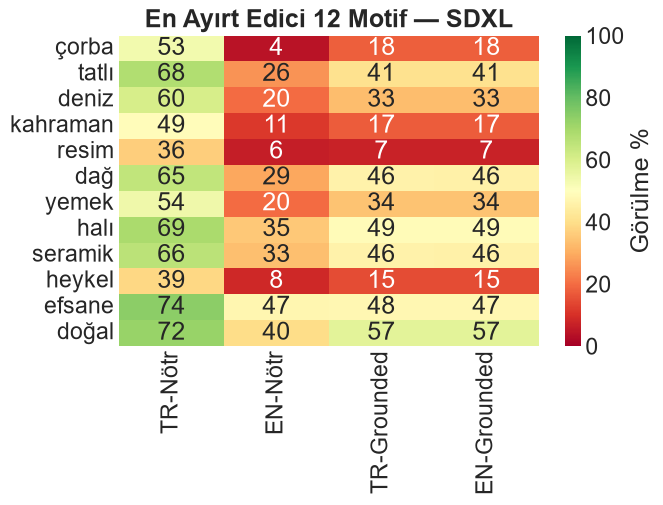

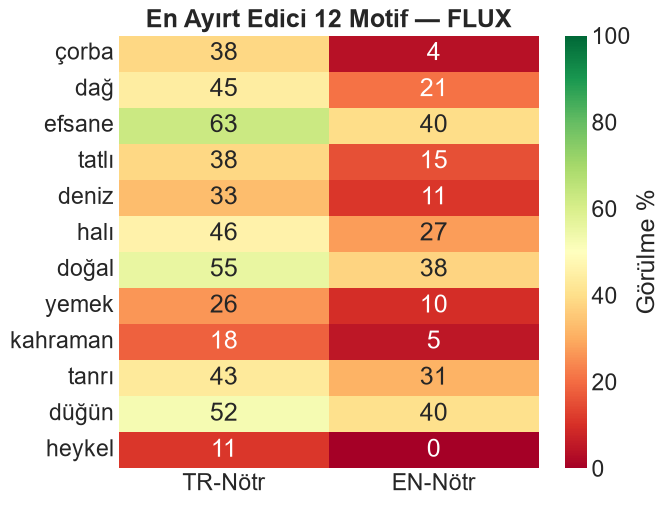

Tam motif tablosu (25 motif) -> motif_heatmap_full.csv (posterde kullanmasan da ekte dursun)


In [60]:
# ============================================================
# 2. TEMIZLENMIS HEATMAP — model basina, en ayirt edici motifler
# ============================================================
if master is not None:
    TOP_N = 12
    for model in master["model"].unique():
        sub = master[master["model"] == model]
        heat = sub.groupby(["motif","condition"])["present"].mean().unstack() * 100
        order = [c for c in ["TR-Nötr","EN-Nötr","TR-Grounded","EN-Grounded"] if c in heat.columns]
        heat = heat[order]
        
        # Motiflerin varyansına göre (farklı koşullar arasındaki değişkenlik) en ayırt edici olanları seç
        top_motifs = heat.var(axis=1).sort_values(ascending=False).head(TOP_N).index
        heat_top = heat.loc[top_motifs]

        # Isı haritasını çiz
        fig, ax = plt.subplots(figsize=(7, max(3.5, 0.45*len(heat_top))))
        sns.heatmap(heat_top, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
                    ax=ax, cbar_kws={"label": "Görülme %"})
        ax.set_title(f"En Ayırt Edici {TOP_N} Motif — {model}", fontweight="bold")
        ax.set_ylabel(""); ax.set_xlabel("")
        fig.tight_layout()
        
        # Görselleri kaydet
        fig.savefig(OUT_DIR / "figures" / f"12_heatmap_clean_{model}.png", dpi=300, bbox_inches="tight")
        fig.savefig(OUT_DIR / "figures" / f"12_heatmap_clean_{model}.pdf", dpi=300, bbox_inches="tight")
        plt.show()

    # --- BURADA DÜZELTME YAPTIM ---
    # tables klasörünün var olup olmadığını kontrol et, yoksa oluştur
    tables_path = OUT_DIR / "tables"
    tables_path.mkdir(parents=True, exist_ok=True) 
    # -----------------------------

    # Tam liste, poster icin degil ama arka planda referans olarak
    full_heat = master.groupby(["motif","model","condition"])["present"].mean().unstack(["model","condition"]) * 100
    full_heat.round(1).to_csv(tables_path / "motif_heatmap_full.csv")
    print("Tam motif tablosu (25 motif) -> motif_heatmap_full.csv (posterde kullanmasan da ekte dursun)")

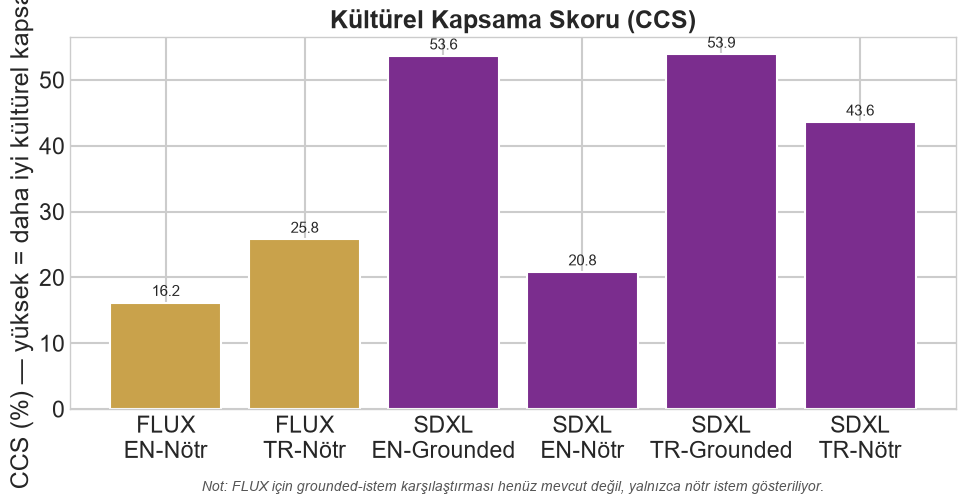

In [61]:
# ============================================================
# 3. CCS BARI — FLUX'ta grounded olmadigi acikca etiketli
# ============================================================
if 'ccs_table' in dir() and not ccs_table.empty:
    tmp = ccs_table.copy()
    tmp["label"] = tmp["model"] + "\n" + tmp["condition"]
    tmp = tmp.sort_values(["model","condition"])

    fig, ax = plt.subplots(figsize=(10, 5.5))
    colors = [MODEL_PALETTE.get(m, "#999") for m in tmp["model"]]
    bars = ax.bar(tmp["label"], tmp["CCS"], color=colors)
    for b, v in zip(bars, tmp["CCS"]):
        ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}", ha="center", fontsize=11)
    ax.set_ylabel("CCS (%) — yüksek = daha iyi kültürel kapsama")
    ax.set_title("Kültürel Kapsama Skoru (CCS)", fontweight="bold")
    ax.text(0.5, -0.22, "Not: FLUX için grounded-istem karşılaştırması henüz mevcut değil, yalnızca nötr istem gösteriliyor.",
            transform=ax.transAxes, ha="center", fontsize=10, style="italic", color="#555")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "13_ccs_honest_bar.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / "figures" / "13_ccs_honest_bar.pdf", dpi=300, bbox_inches="tight")
    plt.show()

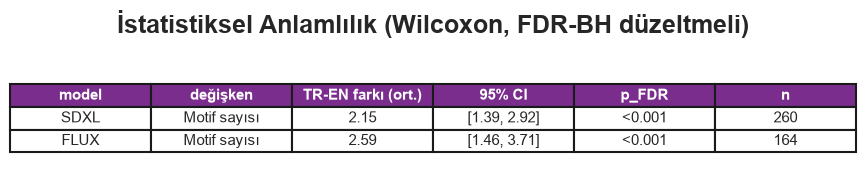

In [62]:
# ============================================================
# 4. ISTATISTIKSEL ANLAMLILIK TABLOSU — poster gorseli olarak
# ============================================================
if 'stats_table' in dir() and not stats_table.empty:
    disp = stats_table.copy()
    disp["TR-EN farkı (ort.)"] = disp["TR-EN farkı (ort.)"].round(2)
    disp["95% CI"] = disp.apply(lambda r: f"[{r['95% CI alt']:.2f}, {r['95% CI üst']:.2f}]", axis=1)
    disp["p_FDR"] = disp["p_FDR"].apply(lambda p: "<0.001" if p < 0.001 else f"{p:.3f}")
    disp = disp[["model","değişken","TR-EN farkı (ort.)","95% CI","p_FDR","n"]]

    fig, ax = plt.subplots(figsize=(9, 0.6*len(disp)+1))
    ax.axis("off")
    tbl = ax.table(cellText=disp.values, colLabels=disp.columns, cellLoc="center", loc="center")
    tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2)
    for j in range(len(disp.columns)):
        tbl[0, j].set_facecolor(PURPLE); tbl[0, j].set_text_props(color="white", fontweight="bold")
    ax.set_title("İstatistiksel Anlamlılık (Wilcoxon, FDR-BH düzeltmeli)", fontweight="bold", pad=20)
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "14_stats_table.png", dpi=300, bbox_inches="tight")
    fig.savefig(OUT_DIR / "figures" / "14_stats_table.pdf", dpi=300, bbox_inches="tight")
    plt.show()

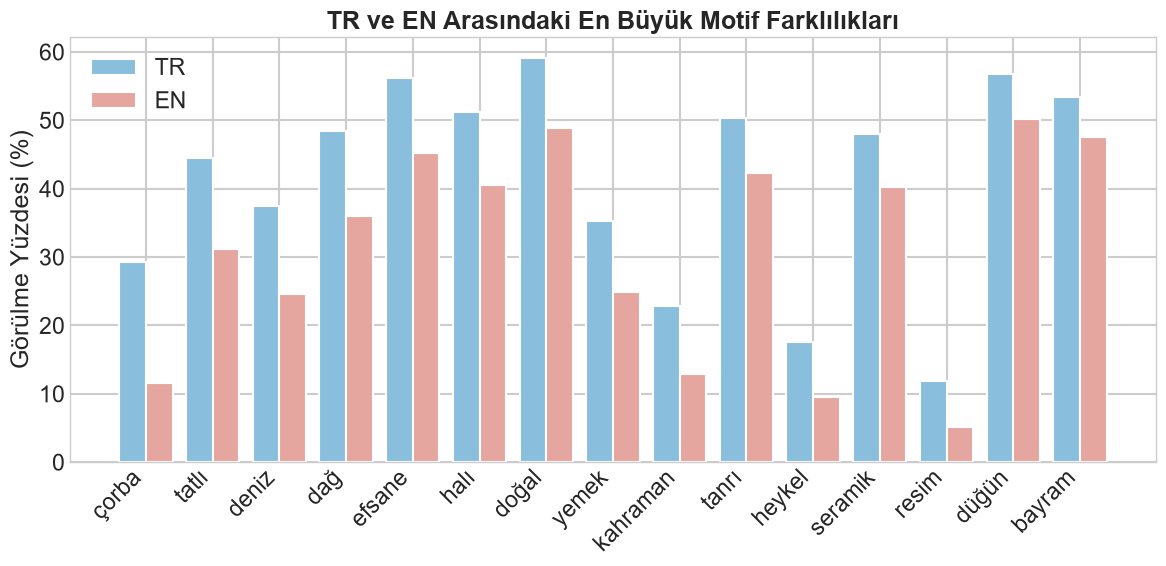

In [74]:
# ============================================================
# ÖNERİ 1: TR vs EN Farkı (En Büyük Farklılıklar)
# ============================================================
if master is not None:
    # Her motif için TR ve EN ortalamalarını hesapla
    motif_means = master.groupby(["motif", "language"])["present"].mean().unstack() * 100
    
    # TR - EN farkını hesapla ve en büyük farklılığa göre sırala
    motif_means["fark"] = (motif_means["TR"] - motif_means["EN"]).abs()
    top_diff = motif_means.sort_values("fark", ascending=False).head(15)
    
    # Grafiği çiz
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(top_diff))
    ax.bar(x, top_diff["TR"], width=0.4, label="TR", color="#8ABEDD", align="center")
    ax.bar([i + 0.4 for i in x], top_diff["EN"], width=0.4, label="EN", color="#E6A6A0", align="center")
    
    ax.set_title("TR ve EN Arasındaki En Büyük Motif Farklılıkları", fontweight="bold")
    ax.set_xticks([i + 0.2 for i in x])
    ax.set_xticklabels(top_diff.index, rotation=45, ha="right")
    ax.legend()
    ax.set_ylabel("Görülme Yüzdesi (%)")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "13_tr_en_fark_bari.png", dpi=300, bbox_inches="tight")
    plt.show()

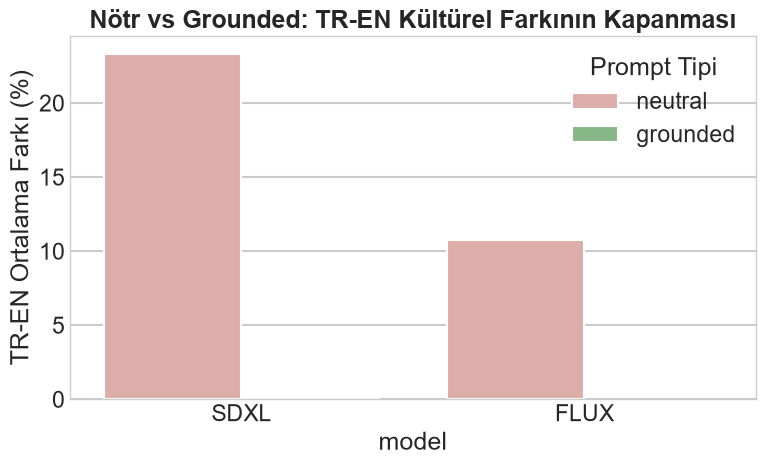

In [75]:
# ============================================================
# ÖNERİ 2: Nötr vs Grounded TR-EN Fark Karşılaştırması
# ============================================================
if master is not None:
    # Her model ve prompt tipi için TR-EN farkını hesapla
    diff_data = []
    for model in master["model"].unique():
        for ptype in master["prompt_type"].unique():
            sub = master[(master["model"]==model) & (master["prompt_type"]==ptype)]
            p_tr = sub[sub.language=="TR"].groupby("motif")["present"].mean()
            p_en = sub[sub.language=="EN"].groupby("motif")["present"].mean()
            diff = (p_tr - p_en).abs().mean() * 100
            diff_data.append({"model": model, "prompt_type": ptype, "diff": diff})
    
    df_diff = pd.DataFrame(diff_data)
    
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(data=df_diff, x="model", y="diff", hue="prompt_type", 
                palette={"neutral": "#E6A6A0", "grounded": "#7FBF7F"}, ax=ax)
    ax.set_title("Nötr vs Grounded: TR-EN Kültürel Farkının Kapanması", fontweight="bold")
    ax.set_ylabel("TR-EN Ortalama Farkı (%)")
    ax.legend(title="Prompt Tipi")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "14_neutral_vs_grounded.png", dpi=300, bbox_inches="tight")
    plt.show()

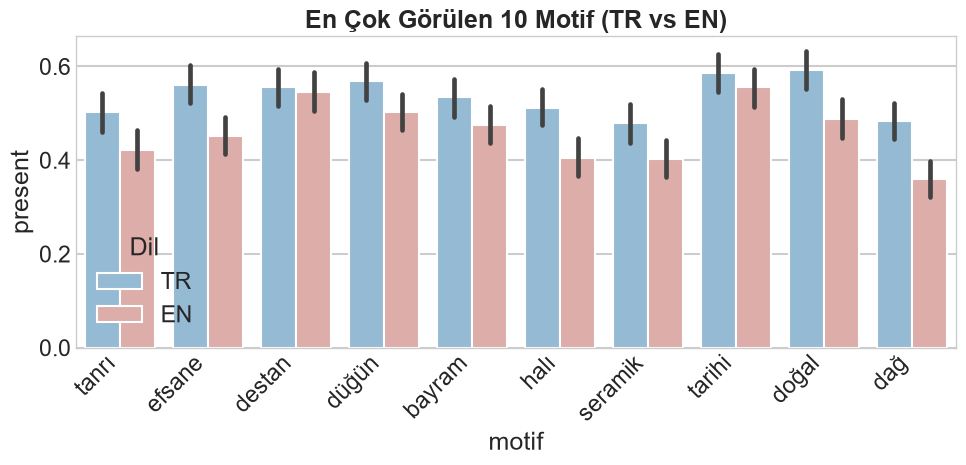

In [76]:
# ============================================================
# ÖNERİ 3: En Çok Görülen Motifler (TR ve EN Karşılaştırmalı)
# ============================================================
if master is not None:
    top_motifs = master.groupby("motif")["present"].mean().sort_values(ascending=False).head(10).index
    df_top = master[master["motif"].isin(top_motifs)]
    
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=df_top, x="motif", y="present", hue="language", 
                palette={"TR": "#8ABEDD", "EN": "#E6A6A0"}, ax=ax)
    ax.set_title("En Çok Görülen 10 Motif (TR vs EN)", fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.legend(title="Dil")
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "15_top_motifs_tr_en.png", dpi=300, bbox_inches="tight")
    plt.show()

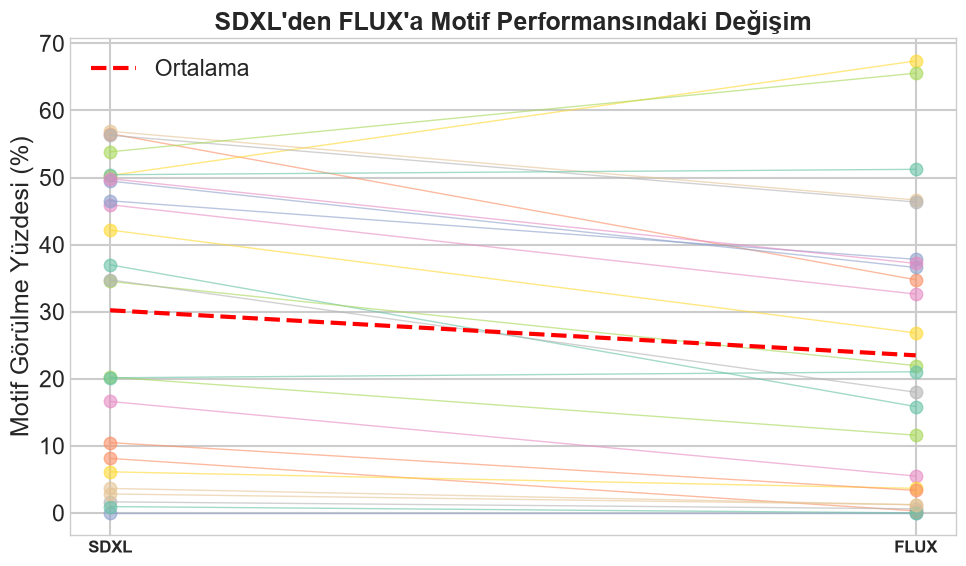

In [77]:
# ============================================================
# ÖNERİ 4: Model Karşılaştırma Slope Grafiği (SDXL vs FLUX)
# ============================================================
if master is not None:
    # Her model için motif ortalamalarını hesapla
    model_means = master.groupby(["model", "motif"])["present"].mean().unstack(level=0) * 100
    
    # Her iki modelde de bulunan motifleri al
    common_motifs = model_means.dropna().index
    
    fig, ax = plt.subplots(figsize=(10, 6))
    for motif in common_motifs:
        ax.plot([0, 1], [model_means.loc[motif, "SDXL"], model_means.loc[motif, "FLUX"]], 
                marker="o", linewidth=1, alpha=0.6)
    
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["SDXL", "FLUX"], fontsize=12, fontweight="bold")
    ax.set_ylabel("Motif Görülme Yüzdesi (%)")
    ax.set_title("SDXL'den FLUX'a Motif Performansındaki Değişim", fontweight="bold")
    
    # Ortalama çizgisini ekle (isteğe bağlı)
    mean_sdxl = model_means["SDXL"].mean()
    mean_flux = model_means["FLUX"].mean()
    ax.plot([0, 1], [mean_sdxl, mean_flux], color="red", linewidth=3, linestyle="--", label="Ortalama")
    ax.legend()
    
    fig.tight_layout()
    fig.savefig(OUT_DIR / "figures" / "16_sdxl_vs_flux_slope.png", dpi=300, bbox_inches="tight")
    plt.show()

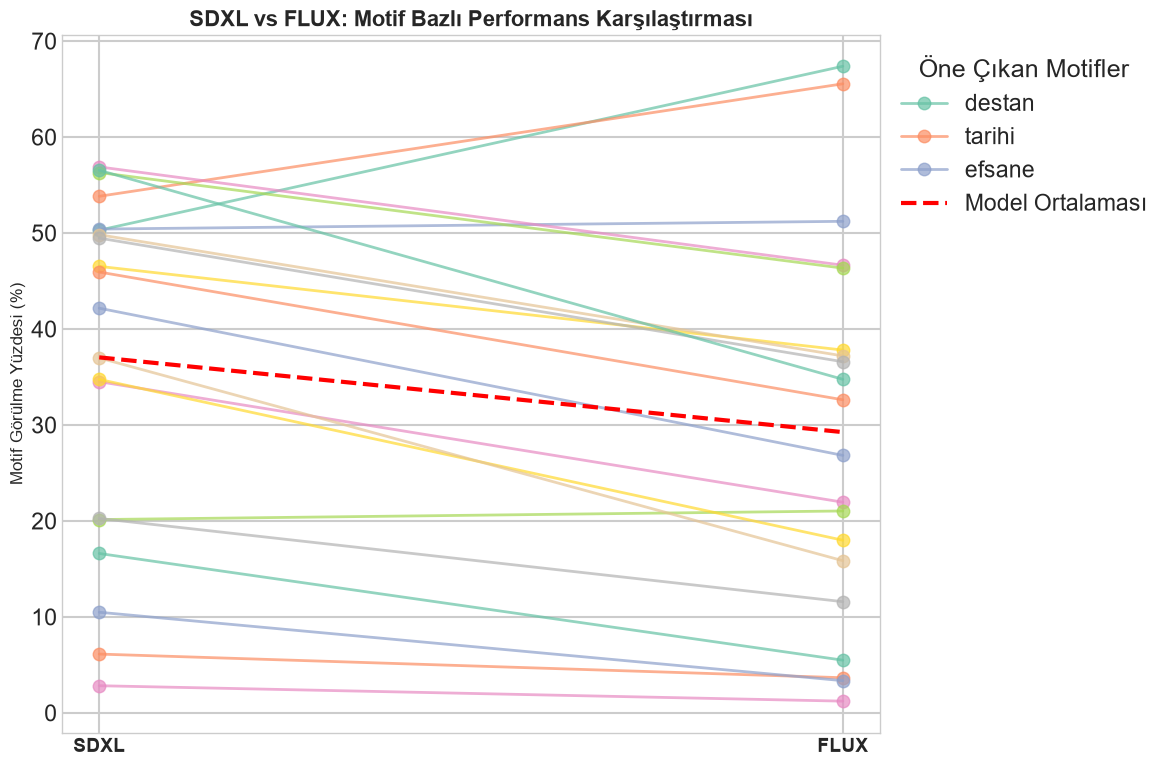

In [78]:
# ============================================================
# SDXL vs FLUX MOTİF KARŞILAŞTIRMASI (SLOPE GRAFİĞİ)
# ============================================================
if master is not None:
    # Her model için motif ortalamalarını hesapla (Yüzde olarak)
    model_means = master.groupby(["model", "motif"])["present"].mean().unstack(level=0) * 100
    
    # Her iki modelde de bulunan motifleri al
    common_motifs = model_means.dropna().index
    df_plot = model_means.loc[common_motifs]
    
    # Motifleri FLUX performansına göre sırala (Görselin daha okunaklı olması için)
    df_plot = df_plot.sort_values("FLUX", ascending=False).head(20) # En iyi 20 motif
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Her motif için çizgi çiz
    for motif in df_plot.index:
        ax.plot([0, 1], [df_plot.loc[motif, "SDXL"], df_plot.loc[motif, "FLUX"]], 
                marker="o", linewidth=2, alpha=0.7, label=motif if df_plot.loc[motif, "FLUX"] > 50 else "")
    
    # SDXL ve FLUX ortalama çizgileri (Kırmızı kesikli çizgi)
    mean_sdxl = df_plot["SDXL"].mean()
    mean_flux = df_plot["FLUX"].mean()
    ax.plot([0, 1], [mean_sdxl, mean_flux], color="red", linewidth=3, linestyle="--", label="Model Ortalaması")
    
    # Eksen ayarları ve başlık
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["SDXL", "FLUX"], fontsize=14, fontweight="bold")
    ax.set_ylabel("Motif Görülme Yüzdesi (%)", fontsize=12)
    ax.set_title("SDXL vs FLUX: Motif Bazlı Performans Karşılaştırması", fontweight="bold", fontsize=16)
    
    # Sadece en yüksek motiflerin isimlerini göster (karışıklığı önlemek için)
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), title="Öne Çıkan Motifler")
    fig.tight_layout()
    
    # Kaydet ve göster
    fig.savefig(OUT_DIR / "figures" / "17_sdxl_vs_flux_slope.png", dpi=300, bbox_inches="tight")
    plt.show()

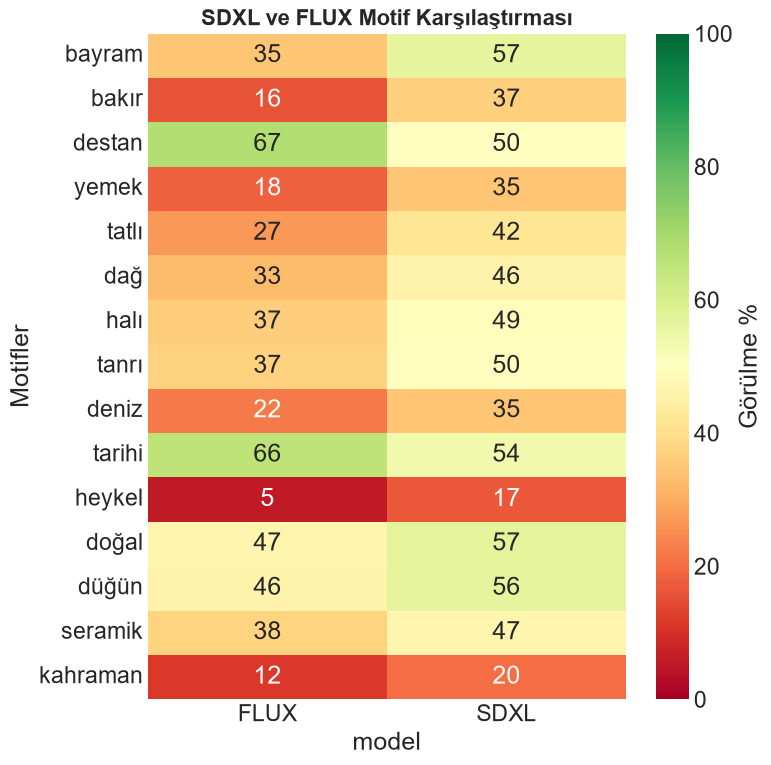

In [79]:
# ============================================================
# SDXL vs FLUX BİRLİKTE ISI HARİTASI
# ============================================================
if master is not None:
    # Veriyi hazırla: Model ve Motife göre ortalama
    heat_data = master.groupby(["motif", "model"])["present"].mean().unstack(level=1) * 100
    
    # En yüksek varyansa sahip (en ilginç) 15 motifi seç
    heat_data["varyans"] = heat_data.var(axis=1)
    heat_data = heat_data.sort_values("varyans", ascending=False).head(15).drop("varyans", axis=1)
    
    fig, ax = plt.subplots(figsize=(8, 8))
    sns.heatmap(heat_data, annot=True, fmt=".0f", cmap="RdYlGn", vmin=0, vmax=100,
                ax=ax, cbar_kws={"label": "Görülme %"})
    ax.set_title("SDXL ve FLUX Motif Karşılaştırması", fontweight="bold", fontsize=16)
    ax.set_ylabel("Motifler")
    fig.tight_layout()
    
    fig.savefig(OUT_DIR / "figures" / "18_model_heatmap_compare.png", dpi=300, bbox_inches="tight")
    plt.show()

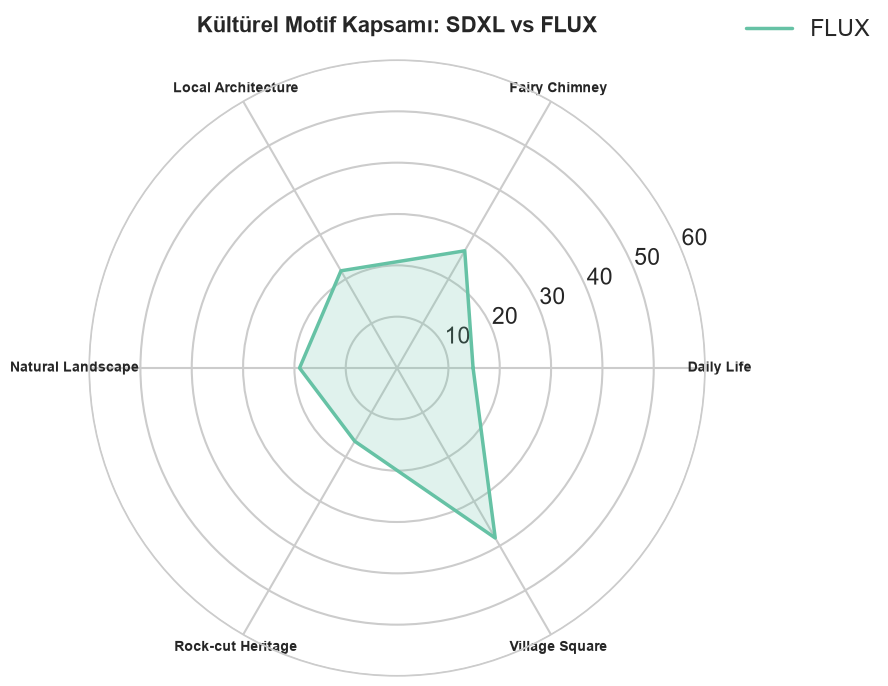

In [81]:
# ============================================================
# SDXL vs FLUX KÜLTÜREL KAPSAMA RADAR GRAFİĞİ (Önerilen)
# ============================================================
if master is not None:
    # Sadece kültürel motifleri filtrele
    cultural = master[master["category"] == "cultural"]
    
    # Tema ve model bazında ortalama kapsamı hesapla
    radar_data = cultural.groupby(["theme", "model"])["present"].mean().unstack(level=1) * 100
    radar_data = radar_data.dropna()
    
    # Temaları ve açıları hazırla
    themes = radar_data.index.tolist()
    angles = np.linspace(0, 2*np.pi, len(themes), endpoint=False).tolist()
    angles += angles[:1]  # Döngüyü kapat
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # Her model için çiz ve doldur
    for model in radar_data.columns:
        values = radar_data[model].tolist()
        values += values[:1]  # Döngüyü kapat
        ax.plot(angles, values, label=model, linewidth=2.5)
        ax.fill(angles, values, alpha=0.2)
    
    # Eksen ayarları
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(themes, fontsize=10, fontweight="bold")
    ax.set_ylim(0, 60)  # Y eksenini 0-60 arasına sabitle (daha iyi görünüm için)
    ax.set_title("Kültürel Motif Kapsamı: SDXL vs FLUX", fontweight="bold", fontsize=16, pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    
    fig.savefig(OUT_DIR / "figures" / "19_radar_sdxl_flux.png", dpi=300, bbox_inches="tight")
    plt.show()